In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from datetime import datetime

# Folder containing fluent_deeponet.py and fno_fluent_dataset.py.
# If the notebook is in the same folder as these files, keep Path.cwd().
MODULE_DIR = Path.cwd()
# MODULE_DIR = Path("/home/hantianl/Documents/PIDIF/your_code_folder")

if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from fluent_deeponet import (
    build_fluent_deeponet_dataset,
    DeepONetPointDataset,
    FeatureNormalizer,
    DeepONet,
    train_deeponet_one_epoch,
    evaluate_deeponet,
    predict_deeponet_full_grid,
)

from eval_fluent_deeponet import (
    load_base_deeponet_checkpoint,
    select_ar_subdomains,
    InterfaceIterationConfig,
    iterative_unknown_interface_inference,
    save_iteration_result_npz,
    stitch_subdomain_grids,
    optimize_interfaces_flux_matching
)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

In [2]:
ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/runs_2d/rect_ar")

train_ars = list(range(10, 31))

case_files = {
    i: {
        "mesh": ROOT_DIR / f"rect_ar{i:02d}_1e-1mps_2c/rect_ar{i:02d}.msh.h5",
        "dat": ROOT_DIR / f"rect_ar{i:02d}_1e-1mps_2c/case2d.dat.h5",
    }
    for i in train_ars
}

for ar, files in case_files.items():
    print(ar, files["mesh"].exists(), files["dat"].exists())


10 True True
11 True True
12 True True
13 True True
14 True True
15 True True
16 True True
17 True True
18 True True
19 True True
20 True True
21 True True
22 True True
23 True True
24 True True
25 True True
26 True True
27 True True
28 True True
29 True True
30 True True


In [3]:
nx = 256
ny = 256
n_subdomains = 10
n_realizations = 20
include_corner_dupes = True

# DeepONet branch sensors:
# x_local, y_local, wall_mask, interface_mask,
# boundary_pressure, boundary_temperature, boundary_u, boundary_v,
# local_aspect_ratio
#
# No left/right-specific channels are used.
deeponet_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    ar_min=10,
    ar_max=30,
    nx=nx,
    ny=ny,
    n_subdomains=n_subdomains,
    include_corner_dupes=include_corner_dupes,
    keep_cases=False,
    interface_placement="random",
    interface_jitter=0,
    rng=np.random.default_rng(),
    n_realizations=n_realizations,
)

branch_inputs = deeponet_data["branch_inputs"].astype(np.float32)
query_coords = deeponet_data["query_coords"].astype(np.float32)
Y = deeponet_data["outputs"].astype(np.float32)

# Guard for an older fluent_deeponet.py build in which each branch row was
# appended twice. This fixes the notebook without editing the helper file.
if branch_inputs.shape[0] != Y.shape[0]:
    if branch_inputs.shape[0] == 2 * Y.shape[0]:
        print("Detected duplicated branch rows; keeping every other branch row.")
        branch_inputs = branch_inputs[::2].copy()
    else:
        raise ValueError(
            f"branch_inputs and Y have incompatible sample counts: "
            f"{branch_inputs.shape[0]} vs {Y.shape[0]}"
        )

branch_channel_names = list(deeponet_data["branch_channel_names"])
trunk_channel_names = list(deeponet_data["trunk_channel_names"])
output_channel_names = list(deeponet_data["output_channel_names"])

ars = np.asarray(deeponet_data["aspect_ratio"]).astype(int)
subdomain_ids = np.asarray(deeponet_data["subdomain_id"]).astype(int)
realizations = np.asarray(deeponet_data["realization_id"]).astype(int)

print("branch_inputs:", branch_inputs.shape)
print("query_coords:", query_coords.shape)
print("Y:", Y.shape)
print("Branch channels:", branch_channel_names)
print("Trunk channels:", trunk_channel_names)
print("Output channels:", output_channel_names)
print("ARs:", sorted(set(ars.tolist())))
print("Subdomains:", sorted(set(subdomain_ids.tolist())))


Processing AR=10 realization=0


Interface locations: [0.0, 194.92599416360758, 249.55117424478675, 503.73320656981923, 665.5881572591451, 817.0099669746837, 914.5291029980409, 1041.0419961613698, 1117.0829072473011, 1203.2867836703576, 1500.0]
Processing AR=10 realization=1
Interface locations: [0.0, 179.43990457422615, 235.9827953878276, 292.44819762126514, 432.69616390756323, 716.865125254813, 941.5613209602516, 1081.334294138811, 1133.4742348798047, 1372.9245529122923, 1500.0]
Processing AR=10 realization=2
Interface locations: [0.0, 378.91536245202684, 436.74251682742556, 757.0398674056265, 777.2830834294067, 978.7519594002079, 1000.5631824815508, 1092.9220181309643, 1157.4870994536227, 1293.0724743238975, 1500.0]
Processing AR=10 realization=3
Interface locations: [0.0, 101.52743520105717, 231.2108298313438, 305.15057103837626, 866.2562715271057, 887.2104402231712, 967.1303709631949, 1040.840552524764, 1067.2462976225015, 1124.4748943002257, 1500.0]
Processing AR=10 realization=4
Interface locations: [0.0, 76.34

In [4]:
# Check the branch representation.
assert not any("left" in name.lower() for name in branch_channel_names)
assert not any("right" in name.lower() for name in branch_channel_names)

wall_mask_ch = branch_channel_names.index("wall_mask")
interface_mask_ch = branch_channel_names.index("interface_mask")
p_ch = branch_channel_names.index("boundary_pressure")
t_ch = branch_channel_names.index("boundary_temperature")
u_ch = branch_channel_names.index("boundary_u")
v_ch = branch_channel_names.index("boundary_v")

sample_id = 0

print("wall mask unique values:", np.unique(branch_inputs[sample_id, :, wall_mask_ch]))
print("interface mask unique values:", np.unique(branch_inputs[sample_id, :, interface_mask_ch]))
print("boundary p range:", branch_inputs[sample_id, :, p_ch].min(), branch_inputs[sample_id, :, p_ch].max())
print("boundary T range:", branch_inputs[sample_id, :, t_ch].min(), branch_inputs[sample_id, :, t_ch].max())
print("boundary u range:", branch_inputs[sample_id, :, u_ch].min(), branch_inputs[sample_id, :, u_ch].max())
print("boundary v range:", branch_inputs[sample_id, :, v_ch].min(), branch_inputs[sample_id, :, v_ch].max())

expected_branch_points = 2 * ny + 2 * nx
print("Expected branch points with corner duplicates:", expected_branch_points)
print("Actual branch points:", branch_inputs.shape[1])


wall mask unique values: [0. 1.]
interface mask unique values: [0. 1.]
boundary p range: 0.0029125675 0.008273231
boundary T range: 273.0 274.9269
boundary u range: 0.0056888694 0.11281818
boundary v range: -0.00563145 0.0056210128
Expected branch points with corner duplicates: 1024
Actual branch points: 1024


In [5]:
valid_ars = [20, 25, 30]

valid_mask = np.isin(ars, valid_ars)
train_mask = ~valid_mask

train_idx = np.flatnonzero(train_mask)
valid_idx = np.flatnonzero(valid_mask)

print("Train samples:", len(train_idx))
print("Valid samples:", len(valid_idx))
print("Train ARs:", sorted(set(ars[train_idx].tolist())))
print("Valid ARs:", sorted(set(ars[valid_idx].tolist())))


Train samples: 3600
Valid samples: 600
Train ARs: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 26, 27, 28, 29]
Valid ARs: [20, 25, 30]


In [6]:
# Normalize branch physical values and local_aspect_ratio.
# Keep normalized coordinates and masks unchanged.
skip_branch_names = [
    "x_local",
    "y_local",
    "wall_mask",
    "interface_mask",
]

skip_branch_indices = [
    branch_channel_names.index(name)
    for name in skip_branch_names
]

branch_normalizer = FeatureNormalizer(
    branch_inputs[train_idx],
    skip_indices=skip_branch_indices,
)

y_normalizer = FeatureNormalizer(Y[train_idx])

print("Branch normalizer mean:", branch_normalizer.mean)
print("Branch normalizer std:", branch_normalizer.std)
print("Y normalizer mean:", y_normalizer.mean)
print("Y normalizer std:", y_normalizer.std)


Branch normalizer mean: tensor([ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  2.2846e-03,
         2.7362e+02,  5.2221e-02, -3.2710e-09,  1.9167e+00])
Branch normalizer std: tensor([1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.8277e-03, 8.5281e-01,
        5.3585e-02, 4.9262e-04, 1.7506e+00])
Y normalizer mean: tensor([ 2.2619e-03,  2.7327e+02,  9.9547e-02, -1.5413e-07])
Y normalizer std: tensor([0.0018, 0.5095, 0.0351, 0.0008])


In [7]:
# The full output grid is still 256 x 256.
# For each training step, DeepONet samples query points from that grid.
# Set N_QUERY_TRAIN = None to use all 65536 points per sample, but that is much heavier.
N_QUERY_TRAIN = None
N_QUERY_VALID = None
BATCH_SIZE = 100

train_ds = DeepONetPointDataset(
    branch_inputs=branch_inputs,
    outputs=Y,
    query_coords=query_coords,
    sample_indices=train_idx,
    n_query_points=N_QUERY_TRAIN,
    random_query=True,
    branch_normalizer=branch_normalizer,
    y_normalizer=y_normalizer,
)

valid_ds = DeepONetPointDataset(
    branch_inputs=branch_inputs,
    outputs=Y,
    query_coords=query_coords,
    sample_indices=valid_idx,
    n_query_points=N_QUERY_VALID,
    random_query=False,
    branch_normalizer=branch_normalizer,
    y_normalizer=y_normalizer,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

branch_batch, query_batch, target_batch, sample_idx_batch = next(iter(train_loader))
print("branch batch:", branch_batch.shape)
print("query batch:", query_batch.shape)
print("target batch:", target_batch.shape)
print("sample indices:", sample_idx_batch)


branch batch: torch.Size([100, 1024, 9])
query batch: torch.Size([100, 65536, 2])
target batch: torch.Size([100, 65536, 4])
sample indices: tensor([ 426, 2298, 3749,  377, 1913, 1291, 3877, 2363, 1912,  562,  951, 3607,
         914, 1084, 2217, 1113, 1539,    9,  671,  284, 2688, 3764,  843, 3563,
        2483, 2509, 1168, 2783, 2815,   78,  356, 2459, 1175, 1608, 3292,  772,
        1819, 1500, 2511, 3270, 1671,  761, 1124, 1886,   22,  683, 3838, 1540,
        3688, 1963,  995, 1309, 3807, 1744,  182, 1341, 1408, 3277, 2589, 1897,
        1377,  330, 3627, 1005, 2658, 3316,  602, 3743, 3599,  187, 2591, 2342,
        1860,  141, 1290, 2858, 2882, 3302,  362, 1890, 3392, 2921, 1811, 1246,
        3346, 3462, 1686, 2595, 1645, 1356, 1481,  115,  344, 1649, 2262, 1651,
        3551, 3381,  487, 2246])


In [8]:
PREFERRED_CUDA_DEVICE = 1
if torch.cuda.is_available():
    if torch.cuda.device_count() > PREFERRED_CUDA_DEVICE:
        DEVICE = torch.device(f"cuda:{PREFERRED_CUDA_DEVICE}")
    else:
        DEVICE = torch.device("cuda:0")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)

EPOCHS = 10000
LEARNING_RATE = 1.0e-3
WEIGHT_DECAY = 1.0e-4

LATENT_DIM = 128
BRANCH_POINT_HIDDEN_DIM = 128
BRANCH_POINT_DEPTH = 3
BRANCH_GLOBAL_HIDDEN_DIM = 128
BRANCH_GLOBAL_DEPTH = 3
TRUNK_HIDDEN_DIM = 128
TRUNK_DEPTH = 4
AGGREGATION = "mean"

model = DeepONet(
    branch_input_dim=branch_inputs.shape[-1],
    trunk_input_dim=query_coords.shape[-1],
    output_channels=Y.shape[-1],
    latent_dim=LATENT_DIM,
    branch_point_hidden_dim=BRANCH_POINT_HIDDEN_DIM,
    branch_point_depth=BRANCH_POINT_DEPTH,
    branch_global_hidden_dim=BRANCH_GLOBAL_HIDDEN_DIM,
    branch_global_depth=BRANCH_GLOBAL_DEPTH,
    trunk_hidden_dim=TRUNK_HIDDEN_DIM,
    trunk_depth=TRUNK_DEPTH,
    aggregation=AGGREGATION,
    activation="gelu",
    layer_norm=False,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)

checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
Path("results").mkdir(parents=True, exist_ok=True)

checkpoint_path = checkpoint_dir / f"deeponet_rect_ar{ars.min():02d}_{ars.max():02d}_RngInt.pt"

best_valid_rel = float("inf")
history = []

# Per-iteration trackers for plotting later.
epoch_list = []
train_loss_per_iter = []
valid_loss_per_iter = []
valid_rel_l2_per_iter = []

# Keep the dataset normalizers on CPU. Use a device copy only for metric decoding.
metric_y_normalizer = FeatureNormalizer.from_state_dict(y_normalizer.state_dict()).to(DEVICE)

Device: cuda:1


In [ ]:
start = datetime.now()
for epoch in range(1, EPOCHS + 1):
    train_loss = train_deeponet_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
        loss_type="mse",
        lambda_bc=0.0,
        branch_normalizer=branch_normalizer,
        y_normalizer=y_normalizer,
        branch_channel_names=branch_channel_names,
    )

    scheduler.step()

    valid_metrics = evaluate_deeponet(
        model=model,
        loader=valid_loader,
        device=DEVICE,
        y_normalizer=metric_y_normalizer,
    )

    valid_mse = float(valid_metrics["mse"])
    valid_rel_l2 = float(valid_metrics["relative_l2"])
    valid_channel_rel_l2 = valid_metrics["channel_relative_l2"]

    epoch_list.append(epoch)
    train_loss_per_iter.append(float(train_loss))
    valid_loss_per_iter.append(valid_mse)
    valid_rel_l2_per_iter.append(valid_rel_l2)

    history.append(
        {
            "epoch": epoch,
            "train_mse_norm": float(train_loss),
            "valid_mse_phys": valid_mse,
            "valid_rel_l2_phys": valid_rel_l2,
            "valid_channel_rel_l2": valid_channel_rel_l2,
        }
    )

    if valid_rel_l2 < best_valid_rel:
        best_valid_rel = valid_rel_l2

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "model_config": model.config(),
                "branch_normalizer": branch_normalizer.state_dict(),
                "y_normalizer": y_normalizer.state_dict(),
                "branch_channel_names": branch_channel_names,
                "trunk_channel_names": trunk_channel_names,
                "output_channel_names": output_channel_names,
                "train_ars": sorted(set(ars[train_idx].tolist())),
                "valid_ars": sorted(set(ars[valid_idx].tolist())),
                "nx": nx,
                "ny": ny,
                "n_subdomains": n_subdomains,
                "include_corner_dupes": include_corner_dupes,
                "n_query_train": N_QUERY_TRAIN,
                "n_query_valid": N_QUERY_VALID,
            },
            checkpoint_path,
        )

    if epoch == 1 or epoch % 10 == 0:
        channel_msg = ", ".join(
            f"{name}={err:.3e}"
            for name, err in zip(output_channel_names, valid_channel_rel_l2)
        )

        print(
            f"Epoch {epoch:04d} | "
            f"train MSE(norm)={train_loss:.3e} | "
            f"valid MSE(phys)={valid_mse:.3e} | "
            f"valid rel L2(phys)={valid_rel_l2:.3e} | "
            f"{channel_msg} | "
            f"time={datetime.now() - start}"
        )

# Save iteration-wise loss history for reuse.
loss_history_path = checkpoint_dir / f"loss_history_deeponet_rect_ar{ars.min():02d}_{ars.max():02d}_RngInt.npz"
np.savez(
    loss_history_path,
    epoch=np.asarray(epoch_list, dtype=np.int32),
    train_mse_norm=np.asarray(train_loss_per_iter, dtype=np.float32),
    valid_mse_phys=np.asarray(valid_loss_per_iter, dtype=np.float32),
    valid_rel_l2_phys=np.asarray(valid_rel_l2_per_iter, dtype=np.float32),
)

print("Best validation relative L2:", best_valid_rel)
print("Saved best checkpoint to:", checkpoint_path)
print("Saved loss history to:", loss_history_path)

Epoch 0001 | train MSE(norm)=6.491e-01 | valid MSE(phys)=2.570e-02 | valid rel L2(phys)=1.169e-03 | pressure=1.224e-01, temperature=1.166e-03, u=3.351e-01, v=7.902e-01 | time=0:00:15.489493


Epoch 0010 | train MSE(norm)=6.958e-02 | valid MSE(phys)=1.267e-03 | valid rel L2(phys)=2.516e-04 | pressure=4.304e-02, temperature=2.594e-04, u=5.818e-02, v=4.529e-01 | time=0:02:37.972158
Epoch 0020 | train MSE(norm)=3.425e-02 | valid MSE(phys)=4.032e-04 | valid rel L2(phys)=1.305e-04 | pressure=2.014e-02, temperature=1.463e-04, u=3.617e-02, v=3.543e-01 | time=0:05:13.124403
Epoch 0030 | train MSE(norm)=2.370e-02 | valid MSE(phys)=2.497e-04 | valid rel L2(phys)=1.084e-04 | pressure=1.614e-02, temperature=1.151e-04, u=2.743e-02, v=2.922e-01 | time=0:07:53.916362
Epoch 0040 | train MSE(norm)=1.700e-02 | valid MSE(phys)=1.851e-04 | valid rel L2(phys)=9.285e-05 | pressure=1.362e-02, temperature=9.917e-05, u=2.262e-02, v=2.525e-01 | time=0:10:32.907696
Epoch 0050 | train MSE(norm)=1.683e-02 | valid MSE(phys)=5.397e-04 | valid rel L2(phys)=1.543e-04 | pressure=1.807e-02, temperature=1.697e-04, u=2.741e-02, v=2.318e-01 | time=0:13:13.132952
Epoch 0060 | train MSE(norm)=1.135e-02 | valid MSE

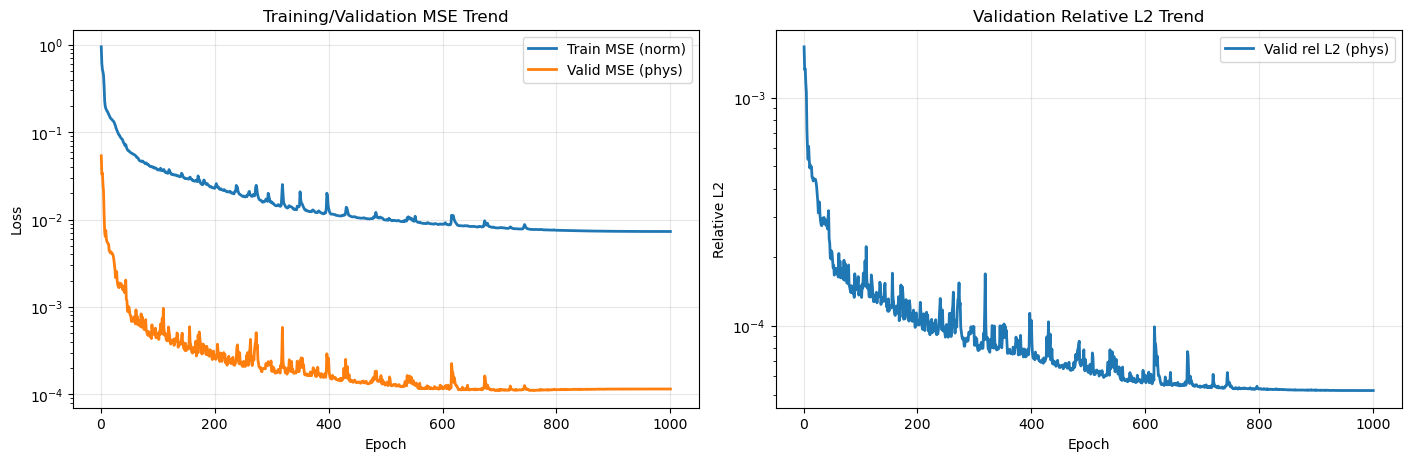

In [ ]:
# Plot training/validation loss trend over iterations (epochs).
epochs = np.asarray(epoch_list)
train_loss_arr = np.asarray(train_loss_per_iter)
valid_loss_arr = np.asarray(valid_loss_per_iter)
valid_rel_l2_arr = np.asarray(valid_rel_l2_per_iter)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(epochs, train_loss_arr, label="Train MSE (norm)", linewidth=2)
axes[0].plot(epochs, valid_loss_arr, label="Valid MSE (phys)", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training/Validation MSE Trend")
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(epochs, valid_rel_l2_arr, label="Valid rel L2 (phys)", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Relative L2")
axes[1].set_title("Validation Relative L2 Trend")
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale("log")
axes[1].legend()

plt.show()


In [ ]:
ckpt = torch.load(checkpoint_path, map_location=DEVICE)

best_model = DeepONet(**ckpt["model_config"]).to(DEVICE)
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()

branch_normalizer_predict = FeatureNormalizer.from_state_dict(
    ckpt["branch_normalizer"]
).to(DEVICE)

y_normalizer_predict = FeatureNormalizer.from_state_dict(
    ckpt["y_normalizer"]
).to(DEVICE)

QUERY_BATCH_SIZE_PRED = 32768

preds = []
truths = []

for sample_id in valid_idx:
    pred_flat = predict_deeponet_full_grid(
        model=best_model,
        branch=branch_inputs[sample_id],
        query_coords=query_coords,
        device=DEVICE,
        branch_normalizer=branch_normalizer_predict,
        y_normalizer=y_normalizer_predict,
        query_batch_size=QUERY_BATCH_SIZE_PRED,
    )
    preds.append(pred_flat.reshape(nx, ny, len(output_channel_names)).numpy())
    truths.append(Y[sample_id])

pred_valid = np.stack(preds, axis=0)
truth_valid = np.stack(truths, axis=0)

print("pred_valid:", pred_valid.shape)
print("truth_valid:", truth_valid.shape)


/tmp/ipykernel_8976/4262124642.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=DEVICE)


pred_valid: (150, 256, 256, 4)
truth_valid: (150, 256, 256, 4)


In [ ]:
valid_ars_tag = "_".join(str(ar) for ar in valid_ars)
pred_path = f"results/valid_predictions_deeponet_ar{valid_ars_tag}_q{N_QUERY_TRAIN}_{EPOCHS}e_RngInt.npz"

np.savez(
    pred_path,
    pred=pred_valid,
    truth=truth_valid,
    valid_indices=valid_idx,
    valid_ars=ars[valid_idx],
    valid_subdomain_ids=subdomain_ids[valid_idx],
    branch_channel_names=np.array(branch_channel_names, dtype=object),
    trunk_channel_names=np.array(trunk_channel_names, dtype=object),
    output_channel_names=np.array(output_channel_names, dtype=object),
)

print("Saved:", pred_path)


Saved: results/valid_predictions_deeponet_ar20_25_30_qNone_1000e_RngInt.npz


Validation sample:
AR: 20
Subdomain: 0
Realization: 3
Stitched subdomains: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


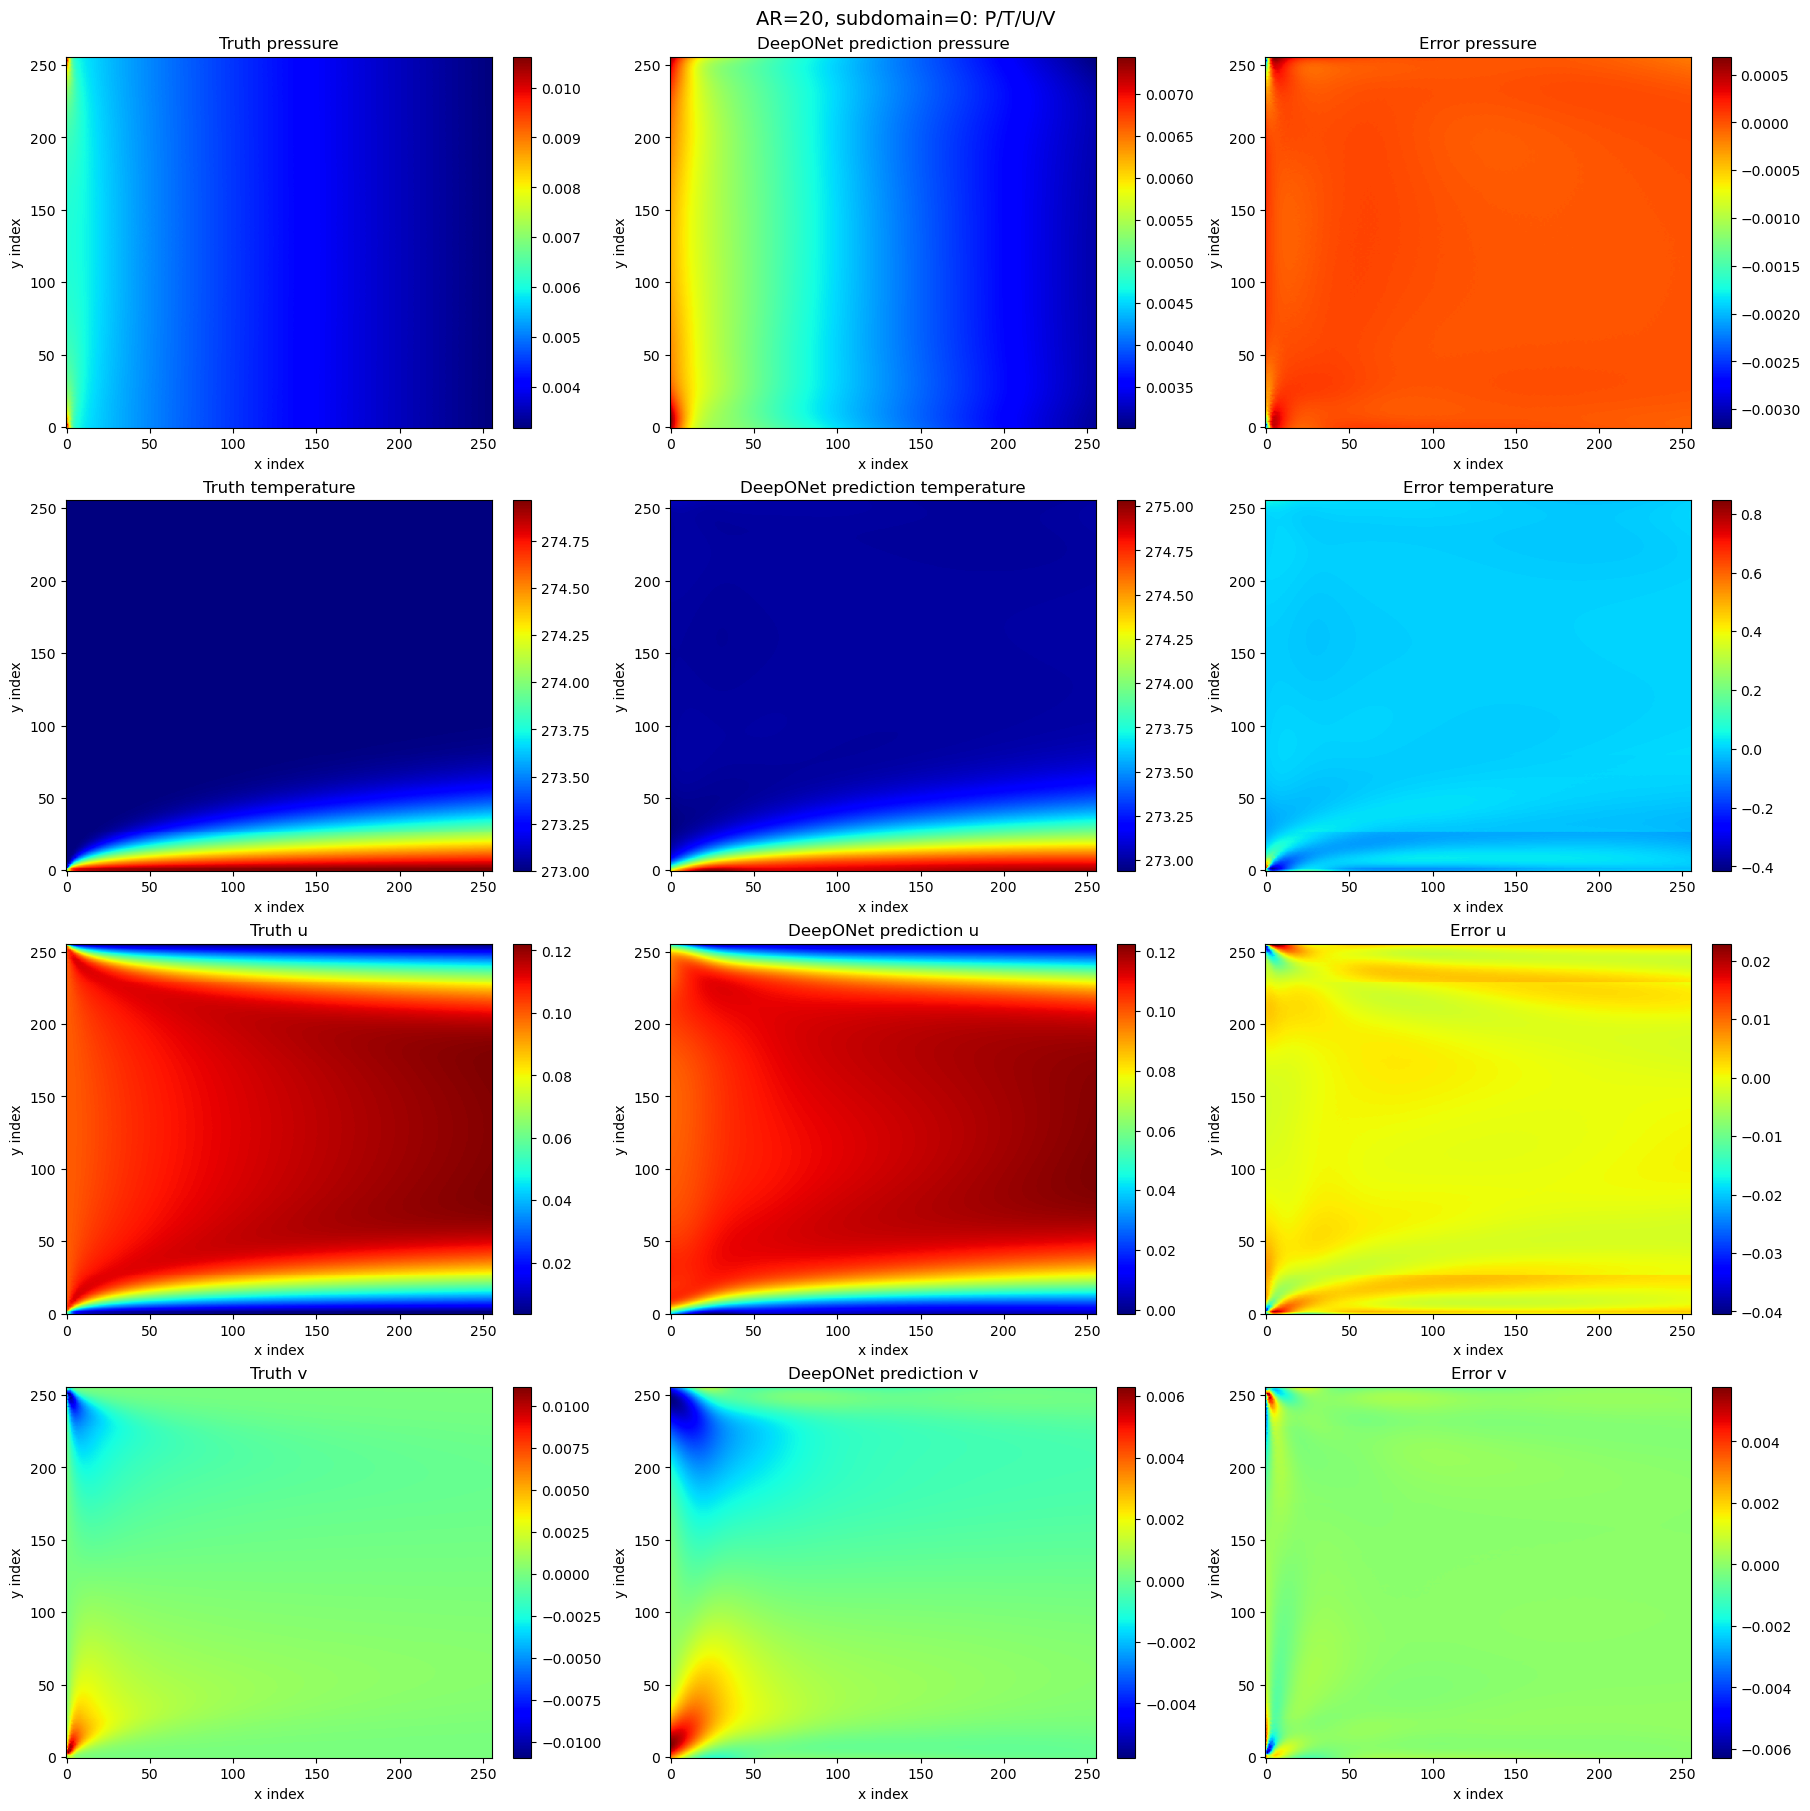

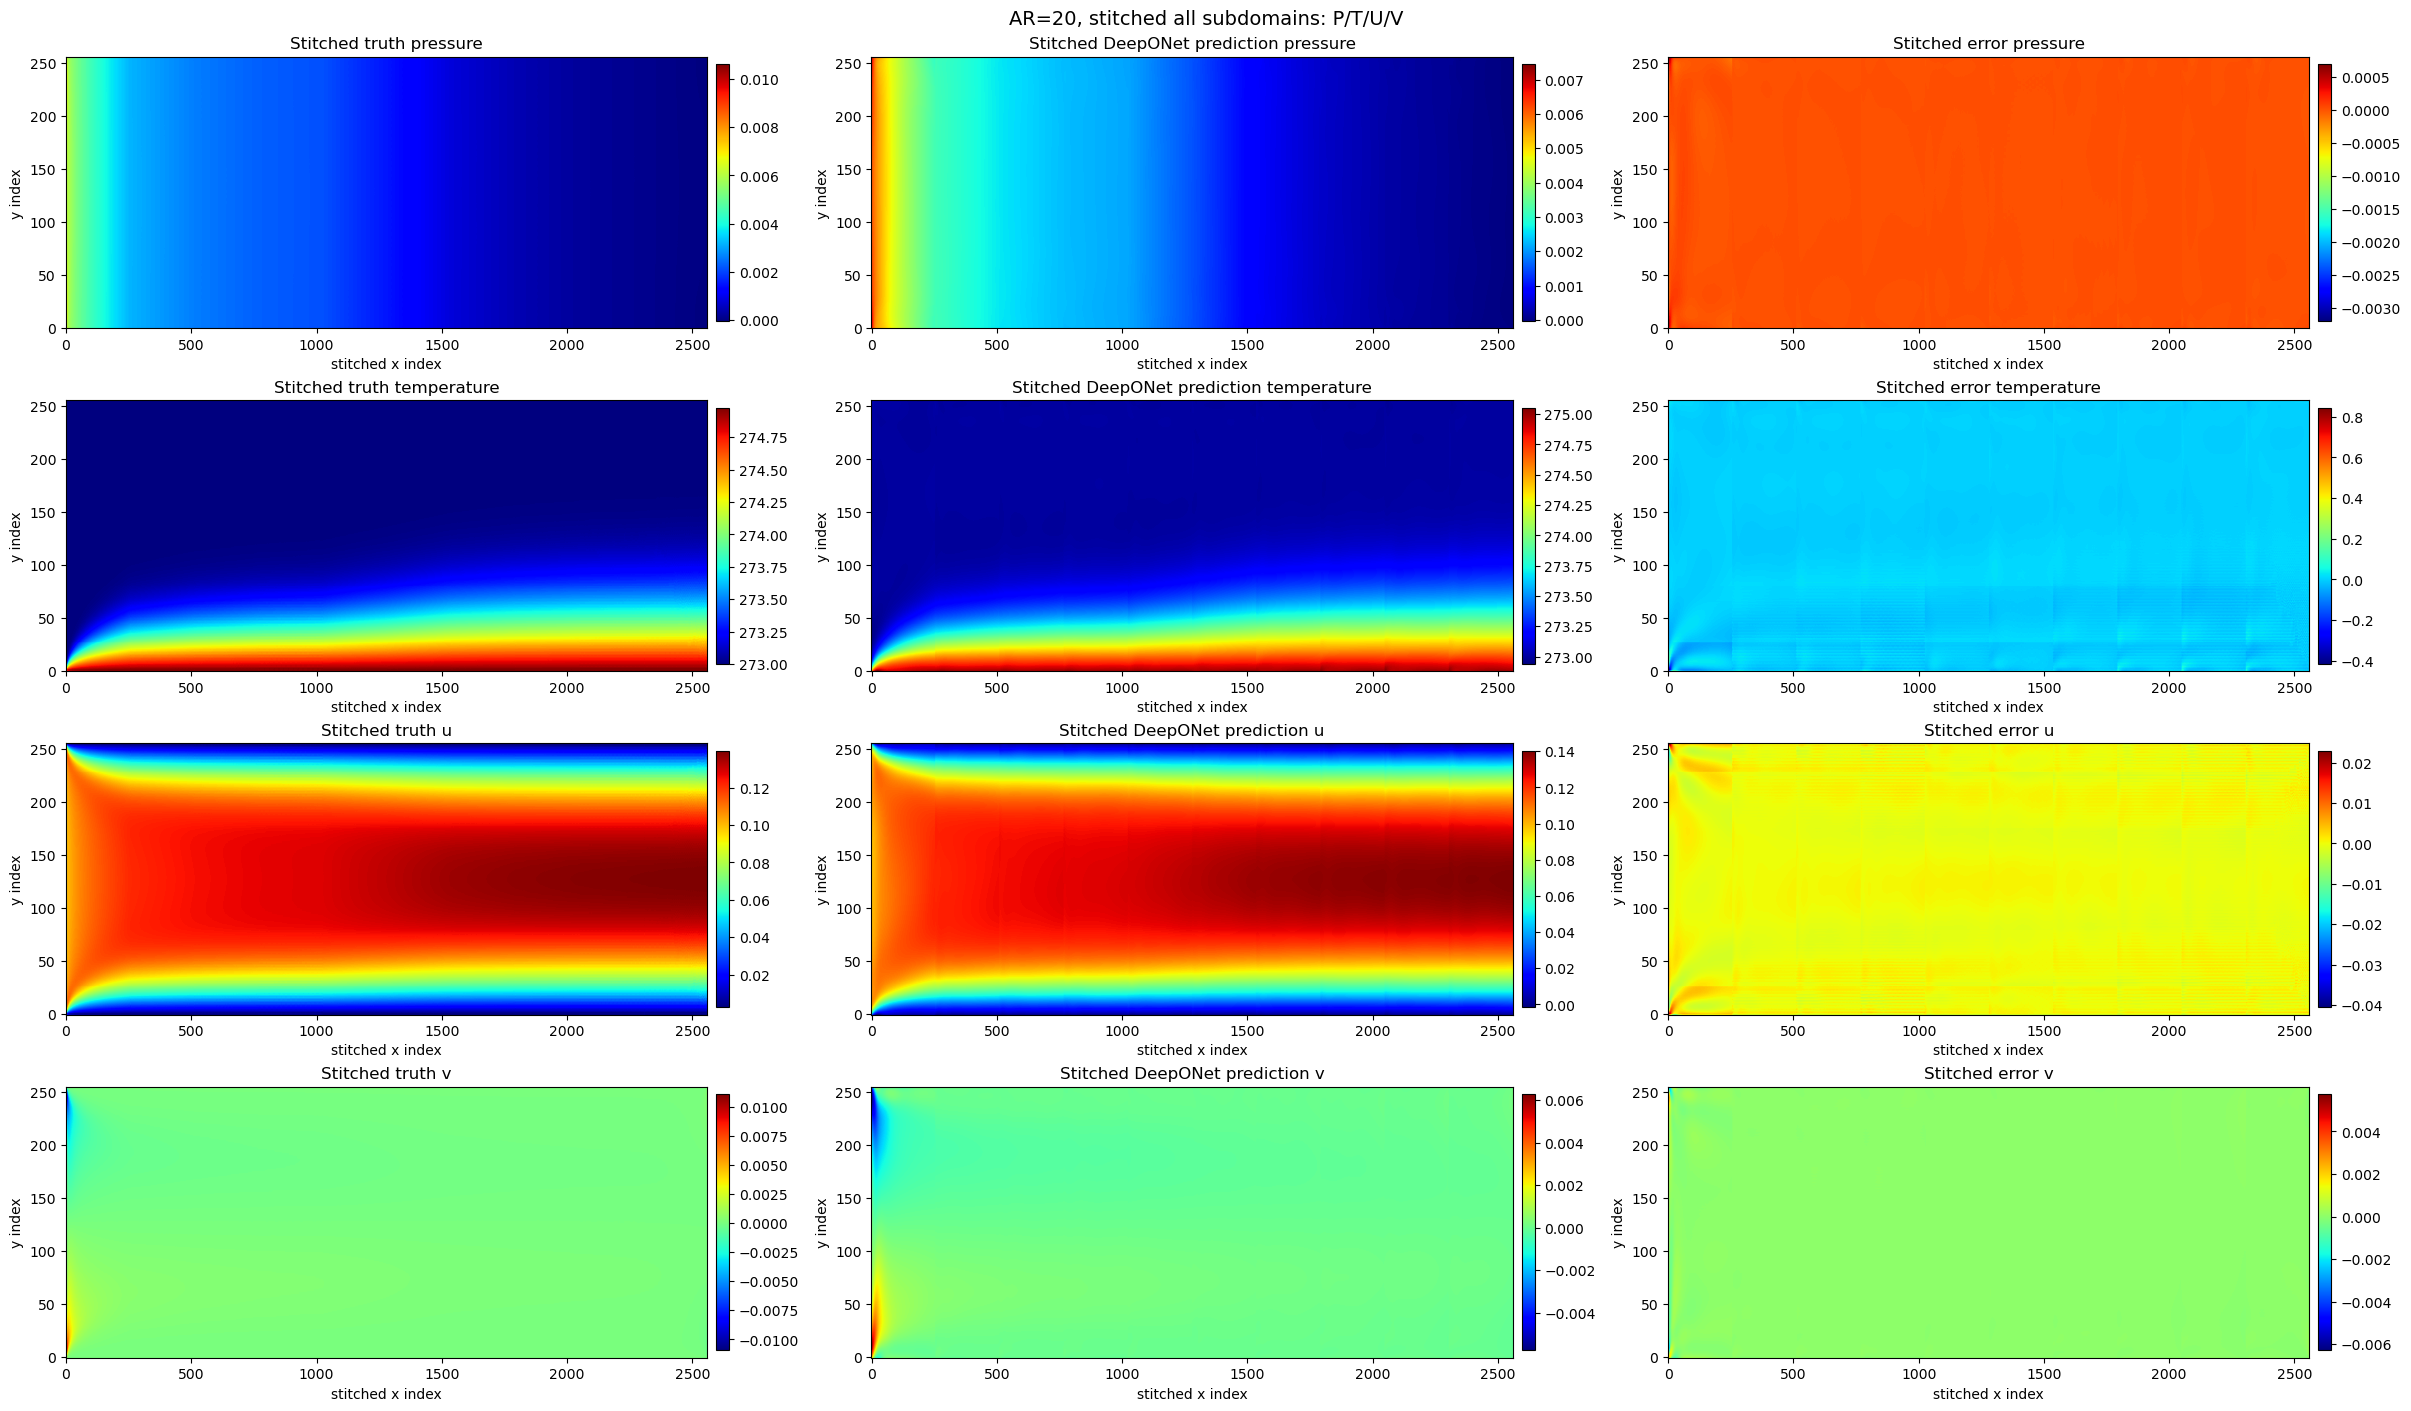

In [ ]:
sample_id = 30
sample_ar = int(ars[valid_idx[sample_id]])
sample_subdomain = int(subdomain_ids[valid_idx[sample_id]])
sample_realization = int(realizations[valid_idx[sample_id]])

# Collect all validation subdomains for this AR geometry,
# sort by subdomain id, and stitch along x for a long-domain plot.
mask = (ars[valid_idx] == sample_ar) & (realizations[valid_idx] == sample_realization)
ar_local_idx = np.flatnonzero(mask)
ar_subdomain_ids = subdomain_ids[valid_idx[ar_local_idx]]
sort_order = np.argsort(ar_subdomain_ids)
ar_local_idx = ar_local_idx[sort_order]
ar_subdomain_ids = ar_subdomain_ids[sort_order]

print("Validation sample:")
print("AR:", sample_ar)
print("Subdomain:", sample_subdomain)
print("Realization:", sample_realization)
print("Stitched subdomains:", ar_subdomain_ids.tolist())

# Figure 1: single subdomain, all fields.
fig1, axes1 = plt.subplots(len(output_channel_names), 3, figsize=(18, 18), constrained_layout=True)

for fi, fname in enumerate(output_channel_names):
    truth_field = truth_valid[sample_id, :, :, fi]
    pred_field = pred_valid[sample_id, :, :, fi]
    err_field = pred_field - truth_field

    im = axes1[fi, 0].imshow(truth_field.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 0].set_title(f"Truth {fname}")
    axes1[fi, 0].set_xlabel("x index")
    axes1[fi, 0].set_ylabel("y index")
    plt.colorbar(im, ax=axes1[fi, 0], fraction=0.046, pad=0.04)

    im = axes1[fi, 1].imshow(pred_field.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 1].set_title(f"DeepONet prediction {fname}")
    axes1[fi, 1].set_xlabel("x index")
    axes1[fi, 1].set_ylabel("y index")
    plt.colorbar(im, ax=axes1[fi, 1], fraction=0.046, pad=0.04)

    im = axes1[fi, 2].imshow(err_field.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 2].set_title(f"Error {fname}")
    axes1[fi, 2].set_xlabel("x index")
    axes1[fi, 2].set_ylabel("y index")
    plt.colorbar(im, ax=axes1[fi, 2], fraction=0.046, pad=0.04)

fig1.suptitle(f"AR={sample_ar}, subdomain={sample_subdomain}: P/T/U/V", fontsize=14)
plt.show()

# Figure 2: stitched all subdomains, all fields.
fig2, axes2 = plt.subplots(len(output_channel_names), 3, figsize=(24, 14), constrained_layout=True)

for fi, fname in enumerate(output_channel_names):
    truth_stitched = np.concatenate([truth_valid[i, :, :, fi] for i in ar_local_idx], axis=0)
    pred_stitched = np.concatenate([pred_valid[i, :, :, fi] for i in ar_local_idx], axis=0)
    err_stitched = pred_stitched - truth_stitched

    im = axes2[fi, 0].imshow(truth_stitched.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 0].set_title(f"Stitched truth {fname}")
    axes2[fi, 0].set_xlabel("stitched x index")
    axes2[fi, 0].set_ylabel("y index")
    plt.colorbar(im, ax=axes2[fi, 0], fraction=0.02, pad=0.01)

    im = axes2[fi, 1].imshow(pred_stitched.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 1].set_title(f"Stitched DeepONet prediction {fname}")
    axes2[fi, 1].set_xlabel("stitched x index")
    axes2[fi, 1].set_ylabel("y index")
    plt.colorbar(im, ax=axes2[fi, 1], fraction=0.02, pad=0.01)

    im = axes2[fi, 2].imshow(err_stitched.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 2].set_title(f"Stitched error {fname}")
    axes2[fi, 2].set_xlabel("stitched x index")
    axes2[fi, 2].set_ylabel("y index")
    plt.colorbar(im, ax=axes2[fi, 2], fraction=0.02, pad=0.01)

fig2.suptitle(f"AR={sample_ar}, stitched all subdomains: P/T/U/V", fontsize=14)
plt.show()


In [ ]:
# --- AR=50 test set with 10 subdomains ---
AR_TEST = 50
TEST_SUBDOMAINS = 20
QUERY_BATCH_SIZE_TEST = 32768

case_files_test = {
    AR_TEST: {
        "mesh": ROOT_DIR / f"rect_ar{AR_TEST:02d}_1e-1mps_2c/rect_ar{AR_TEST:02d}.msh.h5",
        "dat": ROOT_DIR / f"rect_ar{AR_TEST:02d}_1e-1mps_2c/case2d.dat.h5",
    }
}

for name, p in case_files_test[AR_TEST].items():
    print(f"AR={AR_TEST} {name} exists:", p.exists(), p)

test_data = build_fluent_deeponet_dataset(
    case_files=case_files_test,
    ar_min=AR_TEST,
    ar_max=AR_TEST,
    nx=nx,
    ny=ny,
    n_subdomains=TEST_SUBDOMAINS,
    include_corner_dupes=include_corner_dupes,
    keep_cases=False,
)

branch_test = test_data["branch_inputs"].astype(np.float32)
query_coords_test = test_data["query_coords"].astype(np.float32)
Y_test = test_data["outputs"].astype(np.float32)

if branch_test.shape[0] != Y_test.shape[0]:
    if branch_test.shape[0] == 2 * Y_test.shape[0]:
        print("Detected duplicated AR=50 branch rows; keeping every other branch row.")
        branch_test = branch_test[::2].copy()
    else:
        raise ValueError(
            f"branch_test and Y_test have incompatible sample counts: "
            f"{branch_test.shape[0]} vs {Y_test.shape[0]}"
        )

ar_test = np.asarray(test_data["aspect_ratio"]).astype(int)
subdomain_test = np.asarray(test_data["subdomain_id"]).astype(int)

print("branch_test:", branch_test.shape)
print("query_coords_test:", query_coords_test.shape)
print("Y_test:", Y_test.shape)
print("ARs in test set:", sorted(set(ar_test.tolist())))
print("Subdomain IDs in test set:", sorted(set(subdomain_test.tolist())))

pred_test_list = []
truth_test_list = []

for i in range(branch_test.shape[0]):
    pred_flat = predict_deeponet_full_grid(
        model=best_model,
        branch=branch_test[i],
        query_coords=query_coords_test,
        device=DEVICE,
        branch_normalizer=branch_normalizer_predict,
        y_normalizer=y_normalizer_predict,
        query_batch_size=QUERY_BATCH_SIZE_TEST,
    )
    pred_test_list.append(pred_flat.reshape(nx, ny, len(output_channel_names)).numpy())
    truth_test_list.append(Y_test[i])

pred_test = np.stack(pred_test_list, axis=0)
truth_test = np.stack(truth_test_list, axis=0)

# Relative L2 metrics.
num = np.linalg.norm((pred_test - truth_test).reshape(pred_test.shape[0], -1), axis=1)
den = np.linalg.norm(truth_test.reshape(truth_test.shape[0], -1), axis=1) + 1.0e-12
sample_rel_l2 = num / den
overall_rel_l2 = float(np.mean(sample_rel_l2))

per_field_rel_l2 = {}
for fi, fname in enumerate(output_channel_names):
    num_f = np.linalg.norm((pred_test[..., fi] - truth_test[..., fi]).reshape(pred_test.shape[0], -1), axis=1)
    den_f = np.linalg.norm(truth_test[..., fi].reshape(truth_test.shape[0], -1), axis=1) + 1.0e-12
    per_field_rel_l2[fname] = float(np.mean(num_f / den_f))

print(f"AR={AR_TEST} overall relative L2: {overall_rel_l2:.6e}")
for fname in output_channel_names:
    print(f"AR={AR_TEST} {fname} relative L2: {per_field_rel_l2[fname]:.6e}")

pred_path_test = f"results/test_predictions_deeponet_ar{AR_TEST}_sub{TEST_SUBDOMAINS}_q{N_QUERY_TRAIN}_{EPOCHS}e_RngInt.npz"
np.savez(
    pred_path_test,
    pred=pred_test,
    truth=truth_test,
    ar=ar_test,
    subdomain_id=subdomain_test,
    output_channel_names=np.array(output_channel_names, dtype=object),
    sample_rel_l2=sample_rel_l2,
)
print("Saved:", pred_path_test)


AR=50 mesh exists: True /home/hantianl/Documents/PIDIF/runs_2d/rect_ar/rect_ar50_1e-1mps_2c/rect_ar50.msh.h5
AR=50 dat exists: True /home/hantianl/Documents/PIDIF/runs_2d/rect_ar/rect_ar50_1e-1mps_2c/case2d.dat.h5
Processing AR=50 realization=0
Interface locations: [0.0, 375.0, 750.0, 1125.0, 1500.0, 1875.0, 2250.0, 2625.0, 3000.0, 3375.0, 3750.0, 4125.0, 4500.0, 4875.0, 5250.0, 5625.0, 6000.0, 6375.0, 6750.0, 7125.0, 7500.0]
branch_test: (20, 1024, 9)
query_coords_test: (65536, 2)
Y_test: (20, 256, 256, 4)
ARs in test set: [50]
Subdomain IDs in test set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
AR=50 overall relative L2: 1.830150e-04
AR=50 pressure relative L2: 3.763865e-02
AR=50 temperature relative L2: 1.826097e-04
AR=50 u relative L2: 3.080174e-02
AR=50 v relative L2: 2.898061e+00
Saved: results/test_predictions_deeponet_ar50_sub20_qNone_1000e_RngInt.npz


Plotting AR=50 sample index: 0 subdomain: 0
Stitched subdomains: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


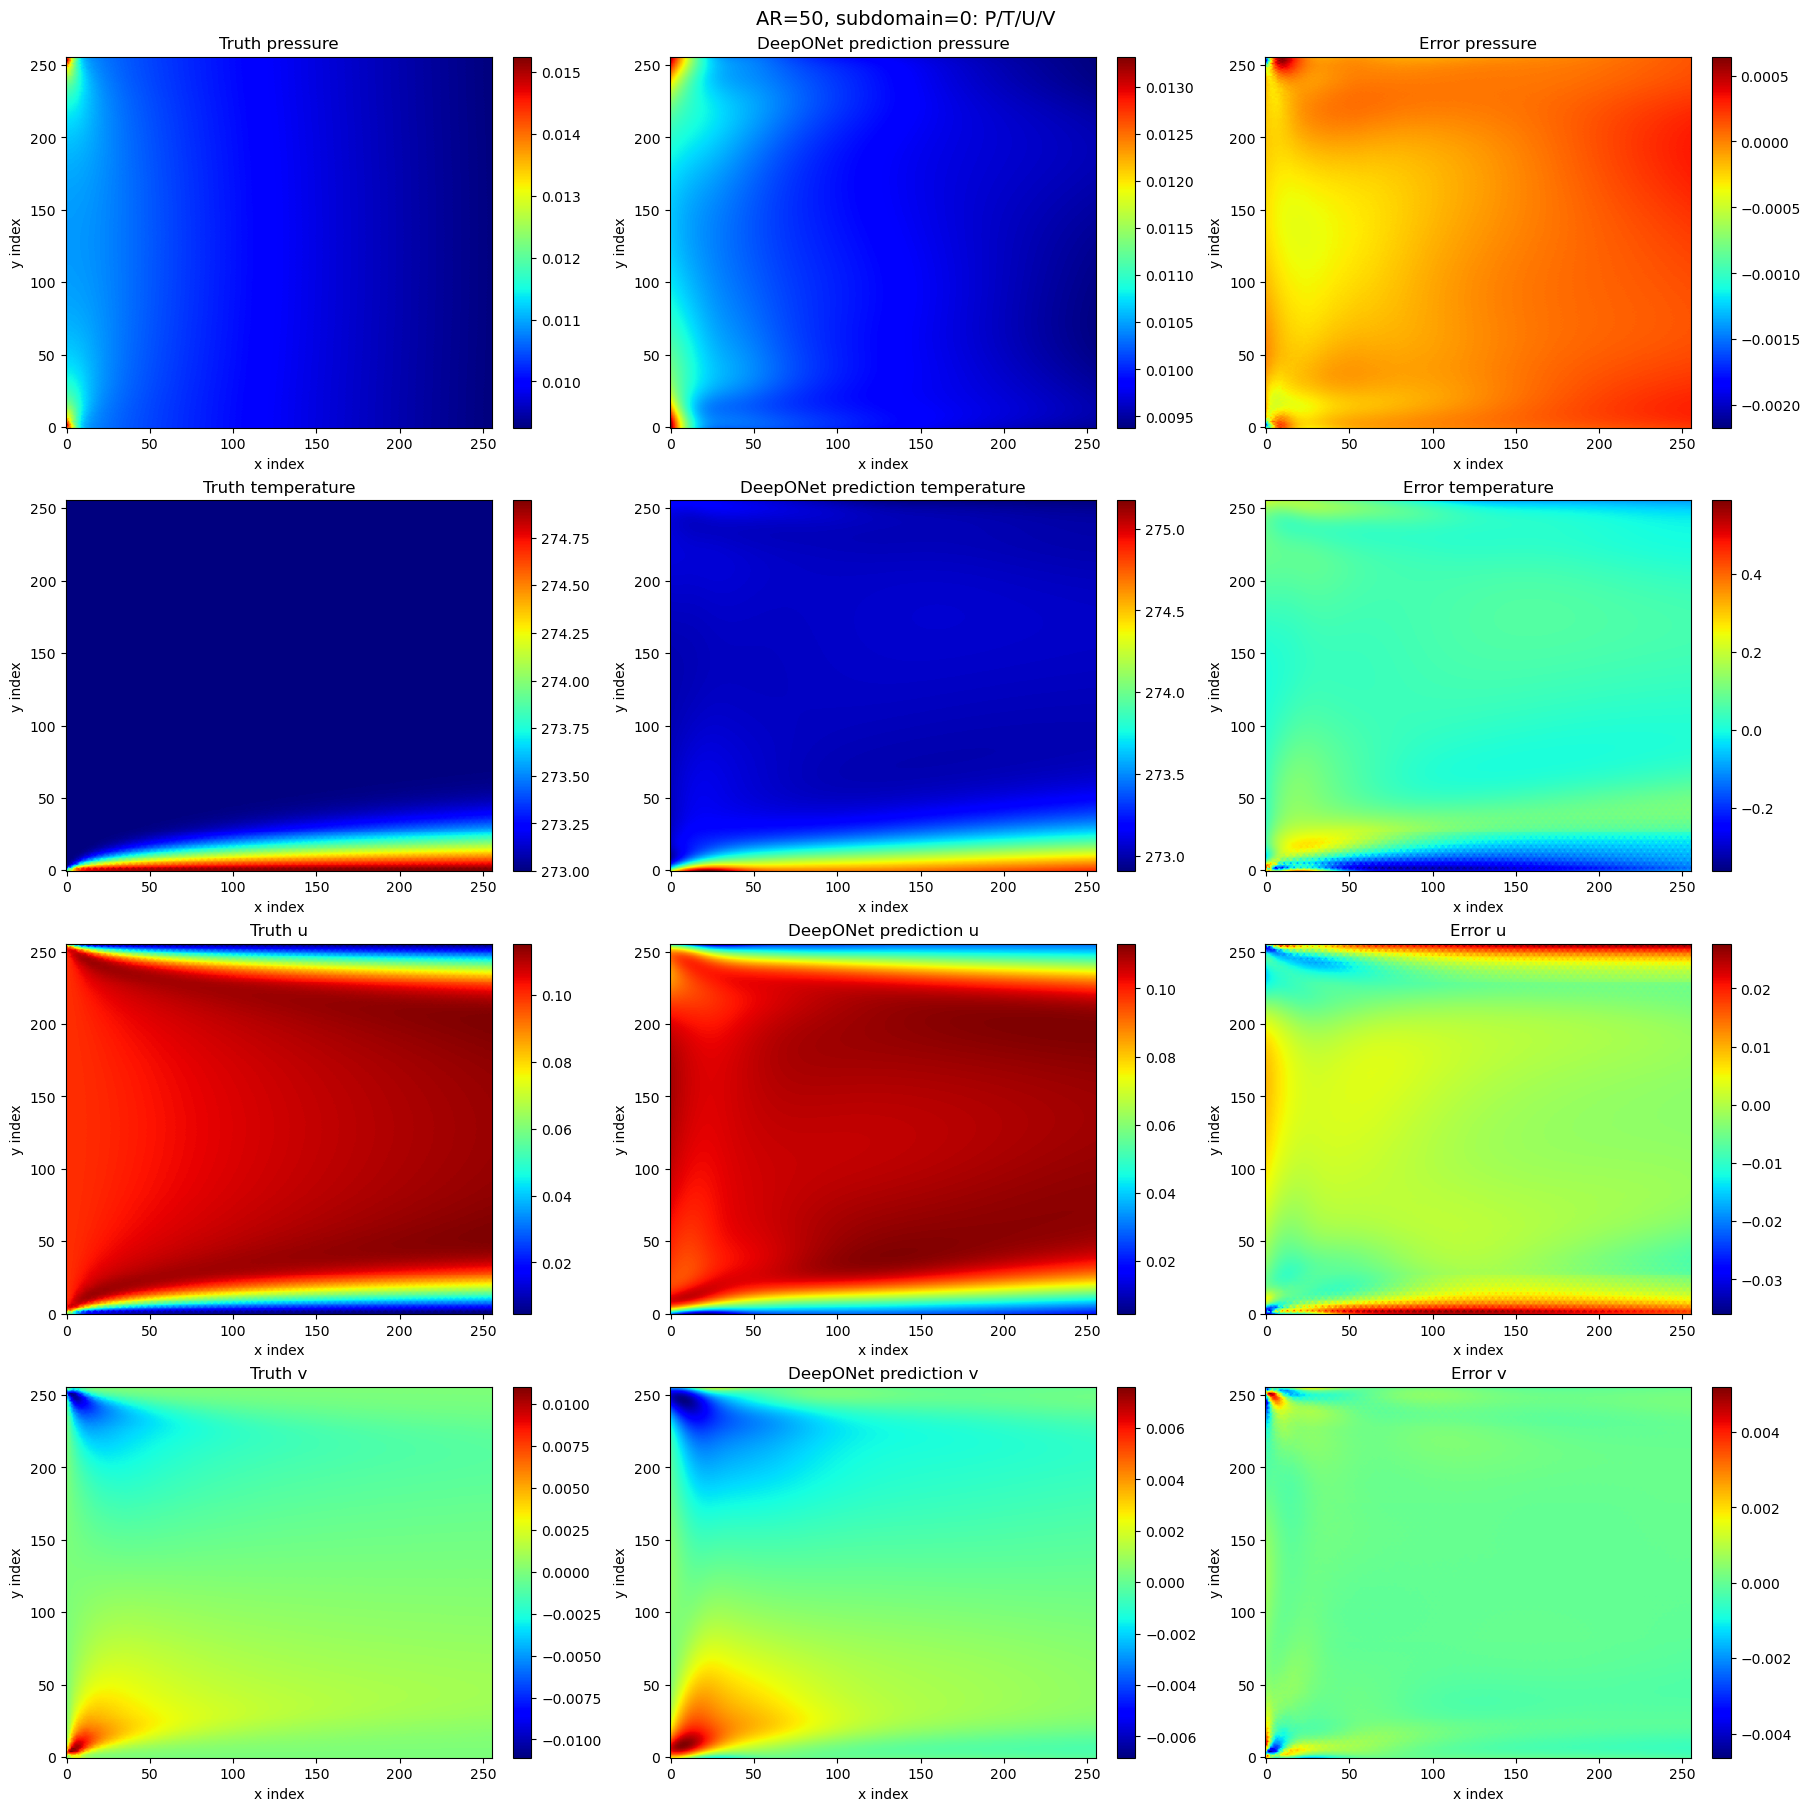

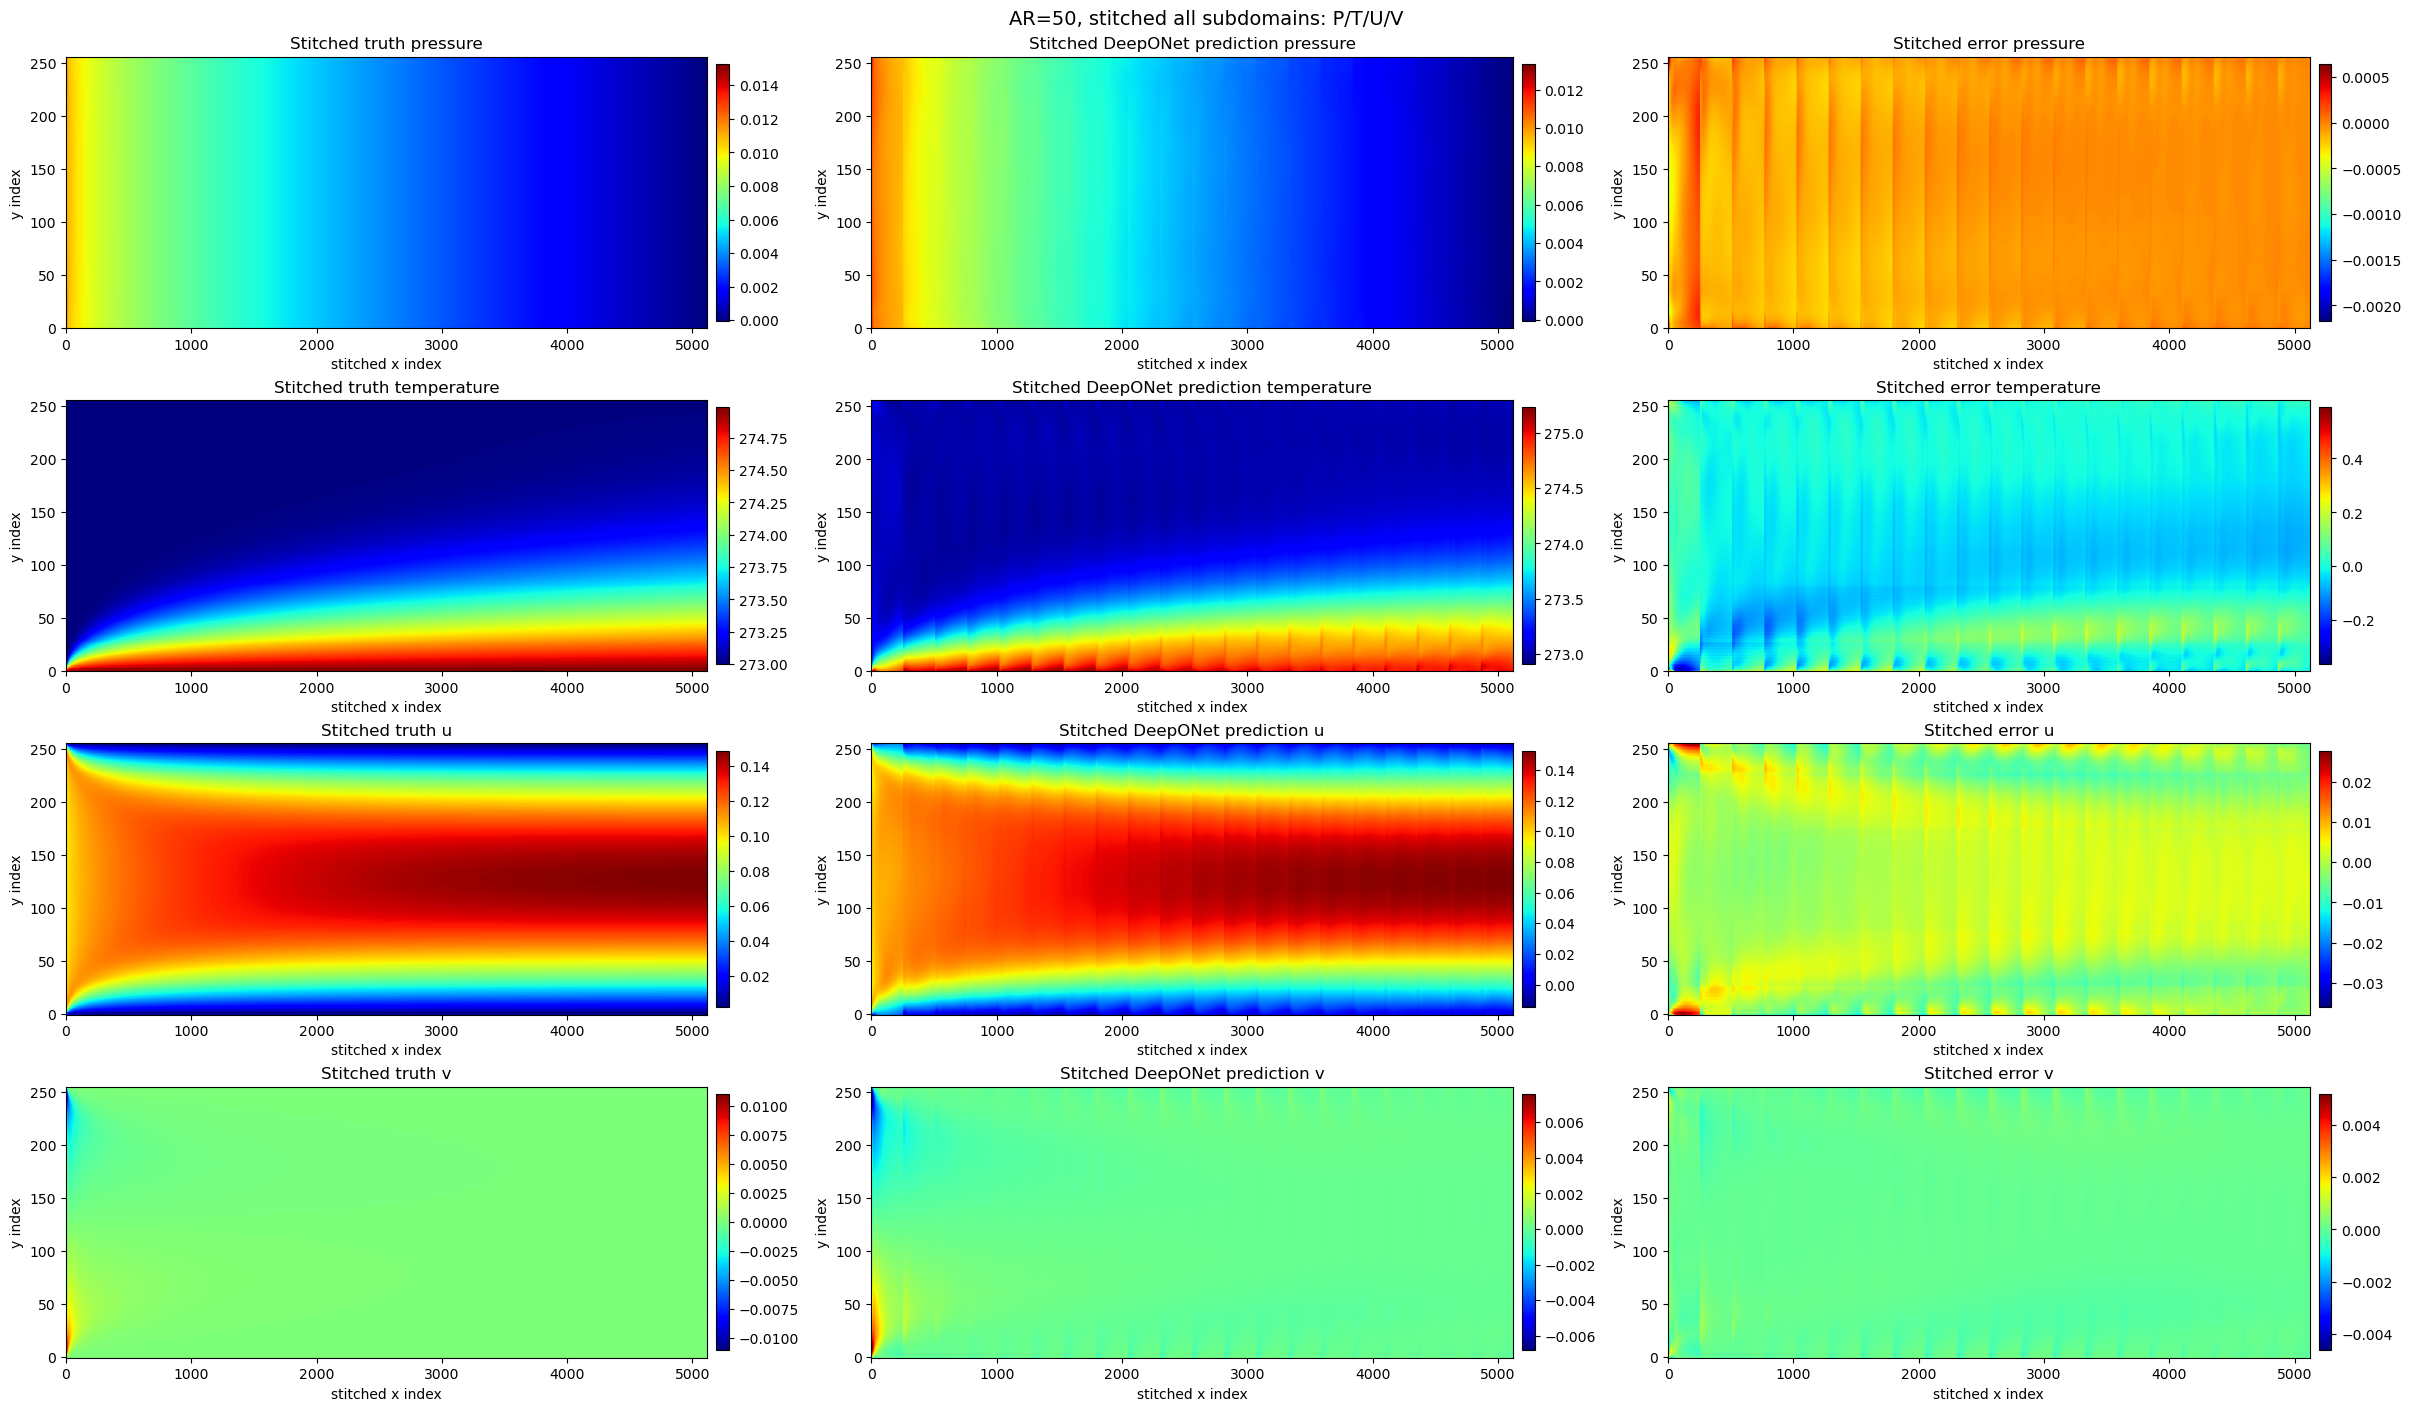

In [ ]:
# --- Plot P/T/U/V on one AR=50 subdomain ---
subdomain_to_plot = 0
sample_candidates = np.where(subdomain_test == subdomain_to_plot)[0]
if len(sample_candidates) == 0:
    raise ValueError(f"Subdomain {subdomain_to_plot} not found in AR={AR_TEST} test set")

sample_idx = int(sample_candidates[0])
print(f"Plotting AR={AR_TEST} sample index:", sample_idx, "subdomain:", subdomain_test[sample_idx])

# Stitched full geometry sorted by subdomain id.
sort_idx = np.argsort(subdomain_test)
subdomain_sorted = subdomain_test[sort_idx]
pred_stitched = np.concatenate([pred_test[i] for i in sort_idx], axis=0)
truth_stitched = np.concatenate([truth_test[i] for i in sort_idx], axis=0)
err_stitched = pred_stitched - truth_stitched
print("Stitched subdomains:", subdomain_sorted.tolist())

# Figure 1: single subdomain.
fig1, axes1 = plt.subplots(len(output_channel_names), 3, figsize=(18, 18), constrained_layout=True)

for fi, fname in enumerate(output_channel_names):
    truth_f = truth_test[sample_idx, :, :, fi]
    pred_f = pred_test[sample_idx, :, :, fi]
    err_f = pred_f - truth_f

    im0 = axes1[fi, 0].imshow(truth_f.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 0].set_title(f"Truth {fname}")
    axes1[fi, 0].set_xlabel("x index")
    axes1[fi, 0].set_ylabel("y index")
    plt.colorbar(im0, ax=axes1[fi, 0], fraction=0.046, pad=0.04)

    im1 = axes1[fi, 1].imshow(pred_f.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 1].set_title(f"DeepONet prediction {fname}")
    axes1[fi, 1].set_xlabel("x index")
    axes1[fi, 1].set_ylabel("y index")
    plt.colorbar(im1, ax=axes1[fi, 1], fraction=0.046, pad=0.04)

    im2 = axes1[fi, 2].imshow(err_f.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 2].set_title(f"Error {fname}")
    axes1[fi, 2].set_xlabel("x index")
    axes1[fi, 2].set_ylabel("y index")
    plt.colorbar(im2, ax=axes1[fi, 2], fraction=0.046, pad=0.04)

fig1.suptitle(f"AR={AR_TEST}, subdomain={subdomain_to_plot}: P/T/U/V", fontsize=14)
plt.show()

# Figure 2: stitched full geometry.
fig2, axes2 = plt.subplots(len(output_channel_names), 3, figsize=(24, 14), constrained_layout=True)

for fi, fname in enumerate(output_channel_names):
    truth_f = truth_stitched[:, :, fi]
    pred_f = pred_stitched[:, :, fi]
    err_f = err_stitched[:, :, fi]

    im0 = axes2[fi, 0].imshow(truth_f.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 0].set_title(f"Stitched truth {fname}")
    axes2[fi, 0].set_xlabel("stitched x index")
    axes2[fi, 0].set_ylabel("y index")
    plt.colorbar(im0, ax=axes2[fi, 0], fraction=0.02, pad=0.01)

    im1 = axes2[fi, 1].imshow(pred_f.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 1].set_title(f"Stitched DeepONet prediction {fname}")
    axes2[fi, 1].set_xlabel("stitched x index")
    axes2[fi, 1].set_ylabel("y index")
    plt.colorbar(im1, ax=axes2[fi, 1], fraction=0.02, pad=0.01)

    im2 = axes2[fi, 2].imshow(err_f.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 2].set_title(f"Stitched error {fname}")
    axes2[fi, 2].set_xlabel("stitched x index")
    axes2[fi, 2].set_ylabel("y index")
    plt.colorbar(im2, ax=axes2[fi, 2], fraction=0.02, pad=0.01)

fig2.suptitle(f"AR={AR_TEST}, stitched all subdomains: P/T/U/V", fontsize=14)
plt.show()


In [ ]:
from eval_fluent_deeponet import infer_edge_layout, initialize_unknown_interior_interfaces

idx_test = select_ar_subdomains(
    test_data,
    ar=AR_TEST,
)

nx = test_data["nx"]
ny = test_data["ny"]
raw_branch = test_data["branch_inputs"][idx_test]
branch_channel_names=test_data["branch_channel_names"]

config = InterfaceIterationConfig(
    max_iter=500,
    tol=1.0e-6,
    mse_mode="normalized",
    relaxation=1,
    random_seed=SEED,
    init_mode="gaussian_along_y",
    init_std_scale=1.0,
    # init_value=0.0,
    init_noise_std=0,
    query_batch_size=32768,
    sample_batch_size=4,
    preserve_wall_corners=False,
    verbose=True,
)

layout = infer_edge_layout(
    branch_template=raw_branch[0],
    branch_channel_names=branch_channel_names,
    nx=int(nx),
    ny=int(ny),
)

if config.init_mode == "dataset_truth":
    current_branch = raw_branch.copy()
else:
    current_branch = initialize_unknown_interior_interfaces(
        branch_inputs_for_ar=raw_branch,
        layout=layout,
        branch_normalizer=branch_normalizer,
        random_seed=config.random_seed,
        init_mode=config.init_mode,
        init_std_scale=config.init_std_scale,
        init_value=config.init_value,
        init_noise_std=config.init_noise_std,
        init_gaussian_center_y=config.init_gaussian_center_y,
        init_gaussian_var_y=config.init_gaussian_var_y,
        preserve_wall_corners=config.preserve_wall_corners,
    )

branch_channel_names

ValueError: operands could not be broadcast together with shapes (256,) (4,) 

In [ ]:
left = []
right = []
for subdomain in current_branch:
    left.append(subdomain[(subdomain[:, 0] == 0) & (subdomain[:, 3] == 1)])
    right.append(subdomain[(subdomain[:, 0] == 1) & (subdomain[:, 3] == 1)])

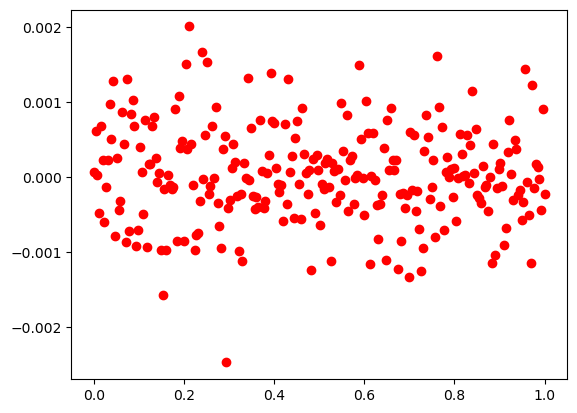

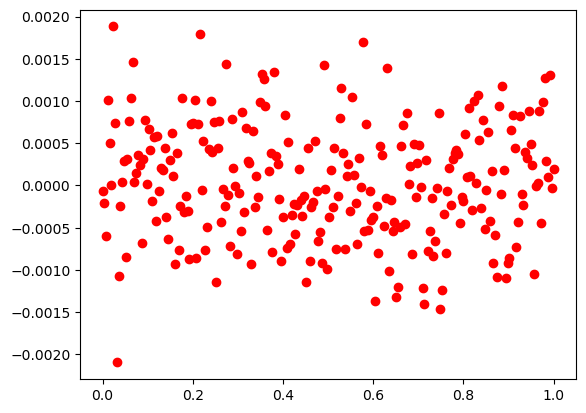

In [ ]:
subdomain = 0
channel = 7

plt.scatter(right[subdomain][:, 1], right[subdomain][:, channel], c='red')
plt.show()

plt.scatter(left[subdomain+1][:, 1], left[subdomain+1][:, channel], c='red')
plt.show()

In [ ]:
idx_test = select_ar_subdomains(
    test_data,
    ar=AR_TEST,
)

config = InterfaceIterationConfig(
    max_iter=500,
    tol=1.0e-6,
    mse_mode="normalized",
    relaxation=1,
    random_seed=SEED,
    init_mode="dataset_truth",
    init_std_scale=1.0,
    init_value=1.0,
    init_noise_std=0,
    query_batch_size=32768,
    sample_batch_size=4,
    preserve_wall_corners=False,
    verbose=True,
)

result = iterative_unknown_interface_inference(
    model=best_model,
    branch_inputs_for_ar=test_data["branch_inputs"][idx_test],
    query_coords=test_data["query_coords"],
    nx=test_data["nx"],
    ny=test_data["ny"],
    branch_channel_names=test_data["branch_channel_names"],
    device=DEVICE,
    branch_normalizer=branch_normalizer,
    y_normalizer=y_normalizer,
    config=config,
)

# result = optimize_interfaces_flux_matching(
#     model=best_model,
#     branch_inputs_for_ar=test_data["branch_inputs"][idx_test],
#     query_coords=test_data["query_coords"],
#     nx=test_data["nx"],
#     ny=test_data["ny"],
#     branch_channel_names=test_data["branch_channel_names"],
#     device=DEVICE,
#     branch_normalizer=branch_normalizer,
#     y_normalizer=y_normalizer,
#     alpha=1.0,
#     beta=0.1,
#     max_iter=200,
#     lr=0.05
# )

iter=0000 | interface MSE max=1.884221e-01, mean=2.376489e-02 | converged=0/19
iter=0001 | interface MSE max=2.900575e-01, mean=3.256624e-02 | converged=0/19
iter=0002 | interface MSE max=3.784820e-01, mean=4.274240e-02 | converged=0/19
iter=0003 | interface MSE max=4.492850e-01, mean=5.515665e-02 | converged=0/19
iter=0004 | interface MSE max=5.055104e-01, mean=7.289658e-02 | converged=0/19
iter=0005 | interface MSE max=5.498723e-01, mean=1.018620e-01 | converged=0/19
iter=0006 | interface MSE max=5.846794e-01, mean=1.522811e-01 | converged=0/19
iter=0007 | interface MSE max=6.118140e-01, mean=2.371391e-01 | converged=0/19
iter=0008 | interface MSE max=9.663088e-01, mean=3.628028e-01 | converged=0/19
iter=0009 | interface MSE max=1.375705e+00, mean=5.269828e-01 | converged=0/19
iter=0010 | interface MSE max=1.819571e+00, mean=7.317155e-01 | converged=0/19
iter=0011 | interface MSE max=2.278507e+00, mean=9.852522e-01 | converged=0/19
iter=0012 | interface MSE max=2.832991e+00, mean=1.2

In [ ]:
pred_subdomains = np.asarray(result["pred_grid"], dtype=np.float32)
pred_stitched = np.asarray(result["pred_stitched"], dtype=np.float32)
print("pred_subdomains:", pred_subdomains.shape)
print("pred_stitched:", pred_stitched.shape)

truth_subdomains = np.asarray(test_data["outputs"][idx_test], dtype=np.float32)
truth_stitched = stitch_subdomain_grids(truth_subdomains)
output_channel_names = list(test_data["output_channel_names"])
print("truth_subdomains:", truth_subdomains.shape)
print("truth_stitched:", truth_stitched.shape)

pred_subdomains: (20, 256, 256, 4)
pred_stitched: (5101, 256, 4)
truth_subdomains: (20, 256, 256, 4)
truth_stitched: (5101, 256, 4)


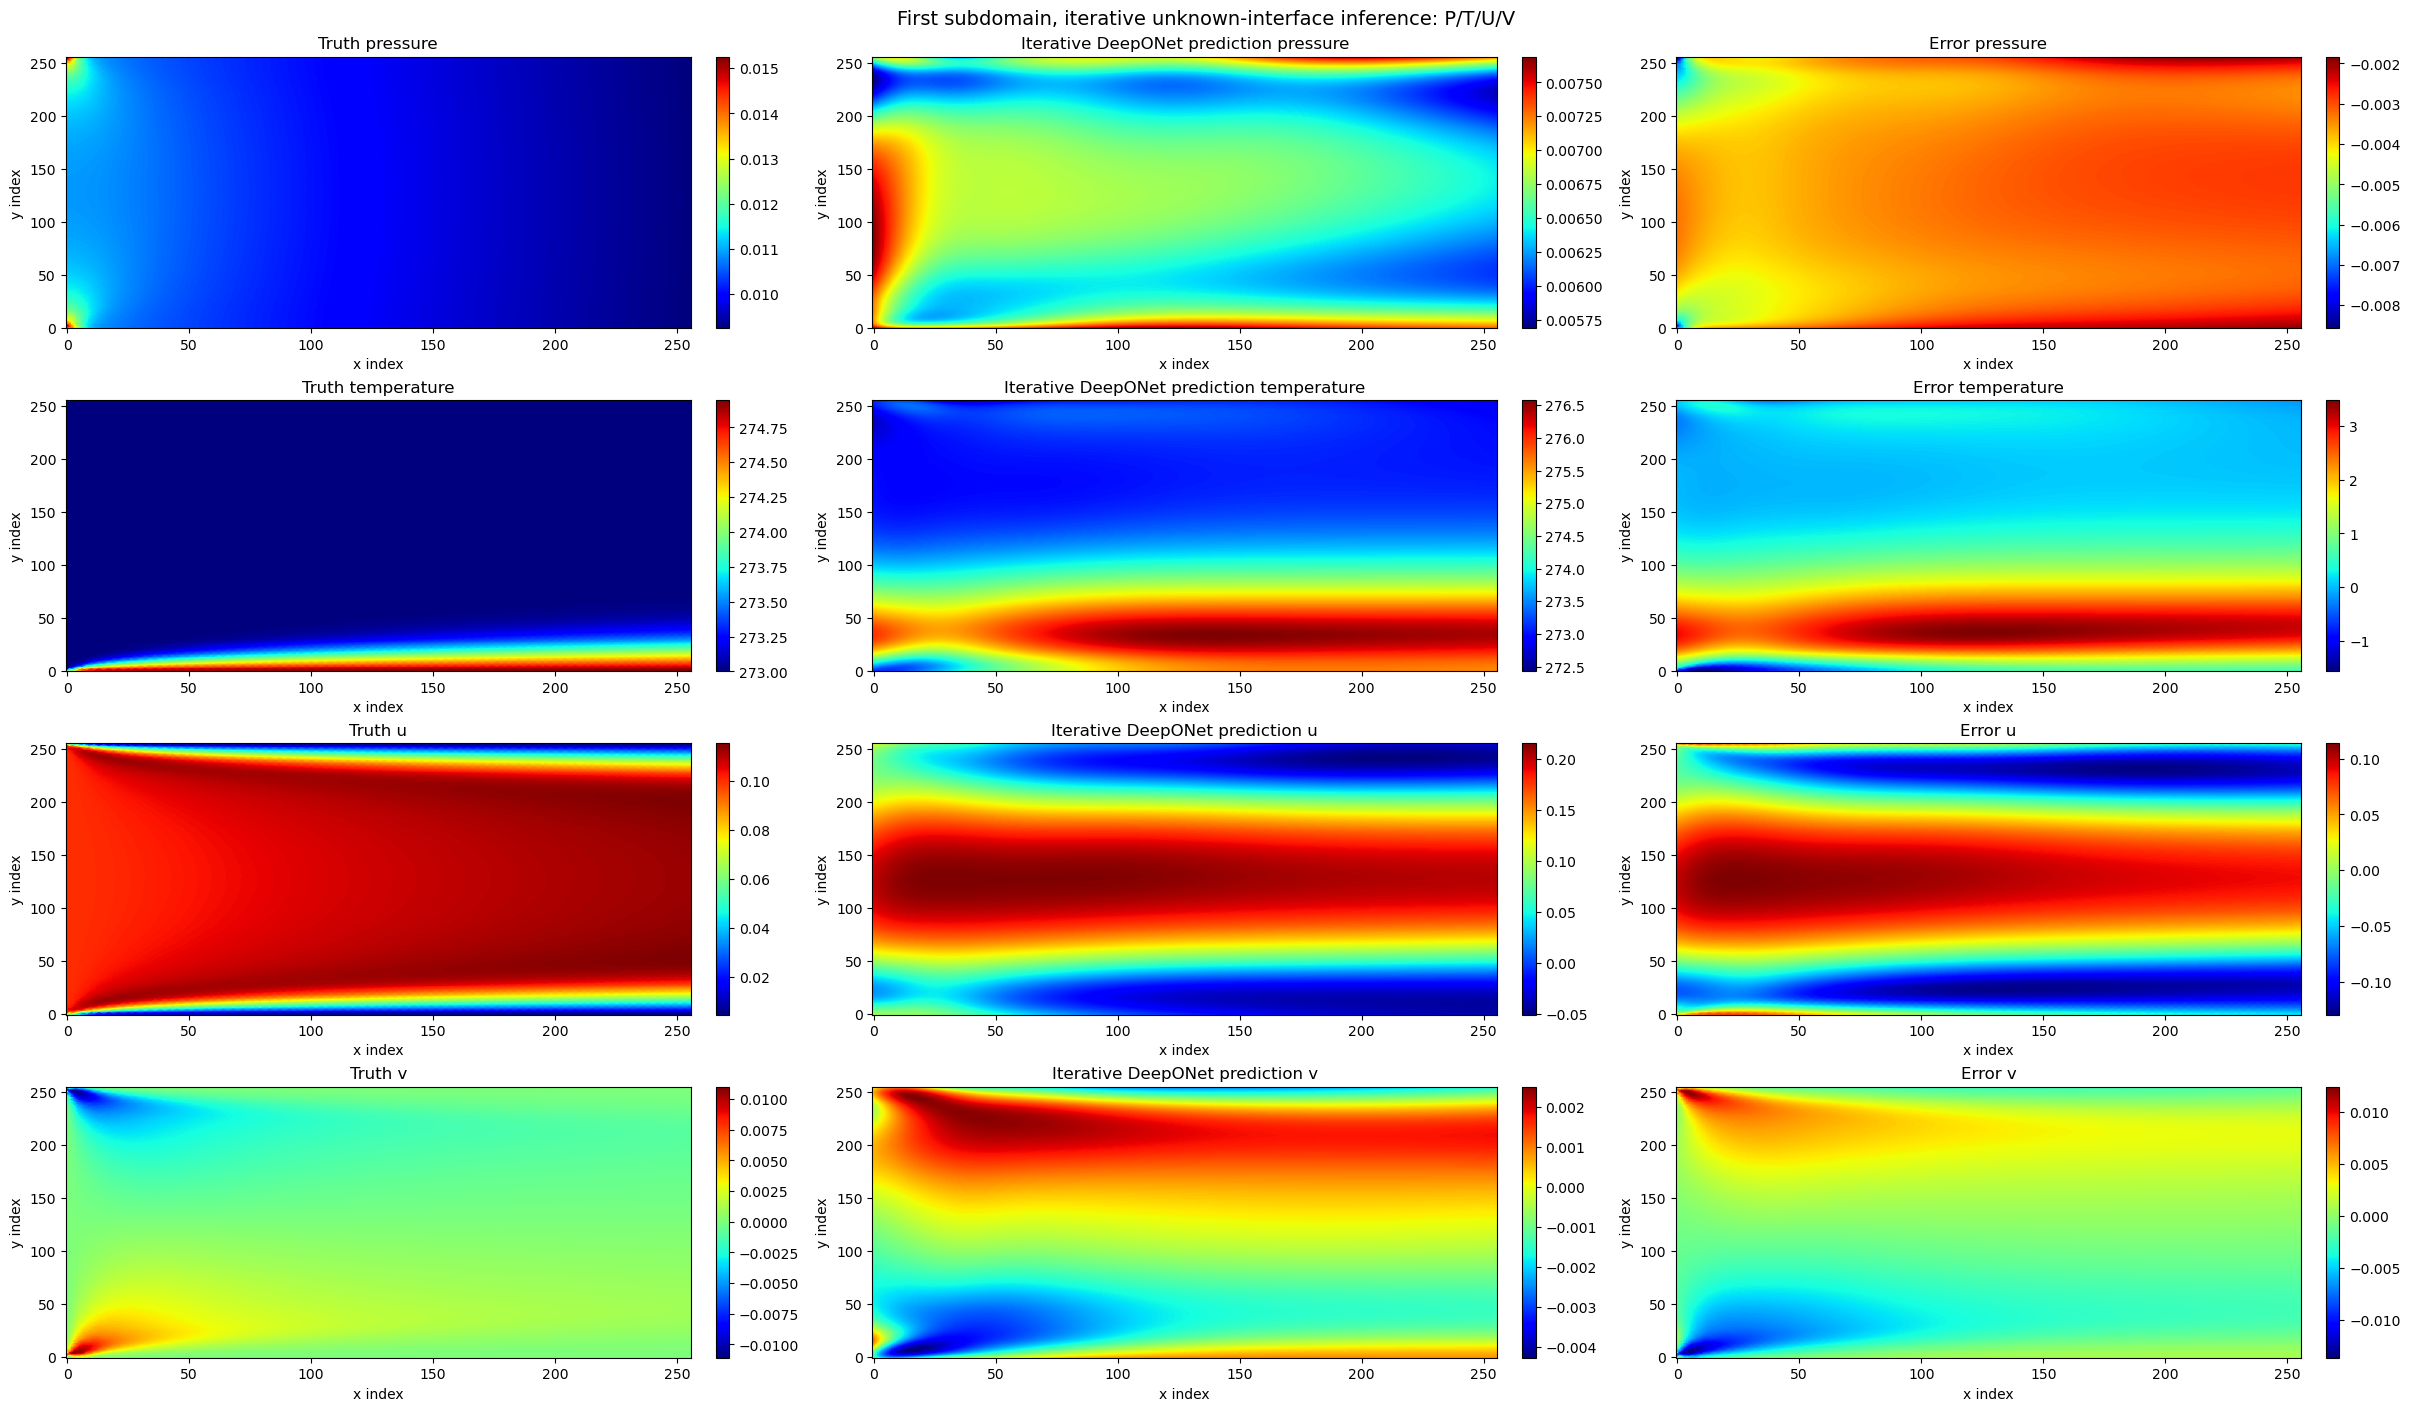

In [ ]:
subdomain_to_plot = 0

pred_one = pred_subdomains[subdomain_to_plot]
truth_one = truth_subdomains[subdomain_to_plot]
err_one = pred_one - truth_one

fig, axes = plt.subplots(
    len(output_channel_names),
    3,
    figsize=(24, 14),
    constrained_layout=True,
)

for fi, fname in enumerate(output_channel_names):
    truth_f = truth_one[:, :, fi]
    pred_f = pred_one[:, :, fi]
    err_f = err_one[:, :, fi]

    im0 = axes[fi, 0].imshow(truth_f.T, origin="lower", aspect="auto", cmap="jet")
    axes[fi, 0].set_title(f"Truth {fname}")
    axes[fi, 0].set_xlabel("x index")
    axes[fi, 0].set_ylabel("y index")
    plt.colorbar(im0, ax=axes[fi, 0], fraction=0.046, pad=0.04)

    im1 = axes[fi, 1].imshow(pred_f.T, origin="lower", aspect="auto", cmap="jet")
    axes[fi, 1].set_title(f"Iterative DeepONet prediction {fname}")
    axes[fi, 1].set_xlabel("x index")
    axes[fi, 1].set_ylabel("y index")
    plt.colorbar(im1, ax=axes[fi, 1], fraction=0.046, pad=0.04)

    im2 = axes[fi, 2].imshow(err_f.T, origin="lower", aspect="auto", cmap="jet")
    axes[fi, 2].set_title(f"Error {fname}")
    axes[fi, 2].set_xlabel("x index")
    axes[fi, 2].set_ylabel("y index")
    plt.colorbar(im2, ax=axes[fi, 2], fraction=0.046, pad=0.04)

fig.suptitle(
    f"First subdomain, iterative unknown-interface inference: P/T/U/V",
    fontsize=14,
)
plt.show()

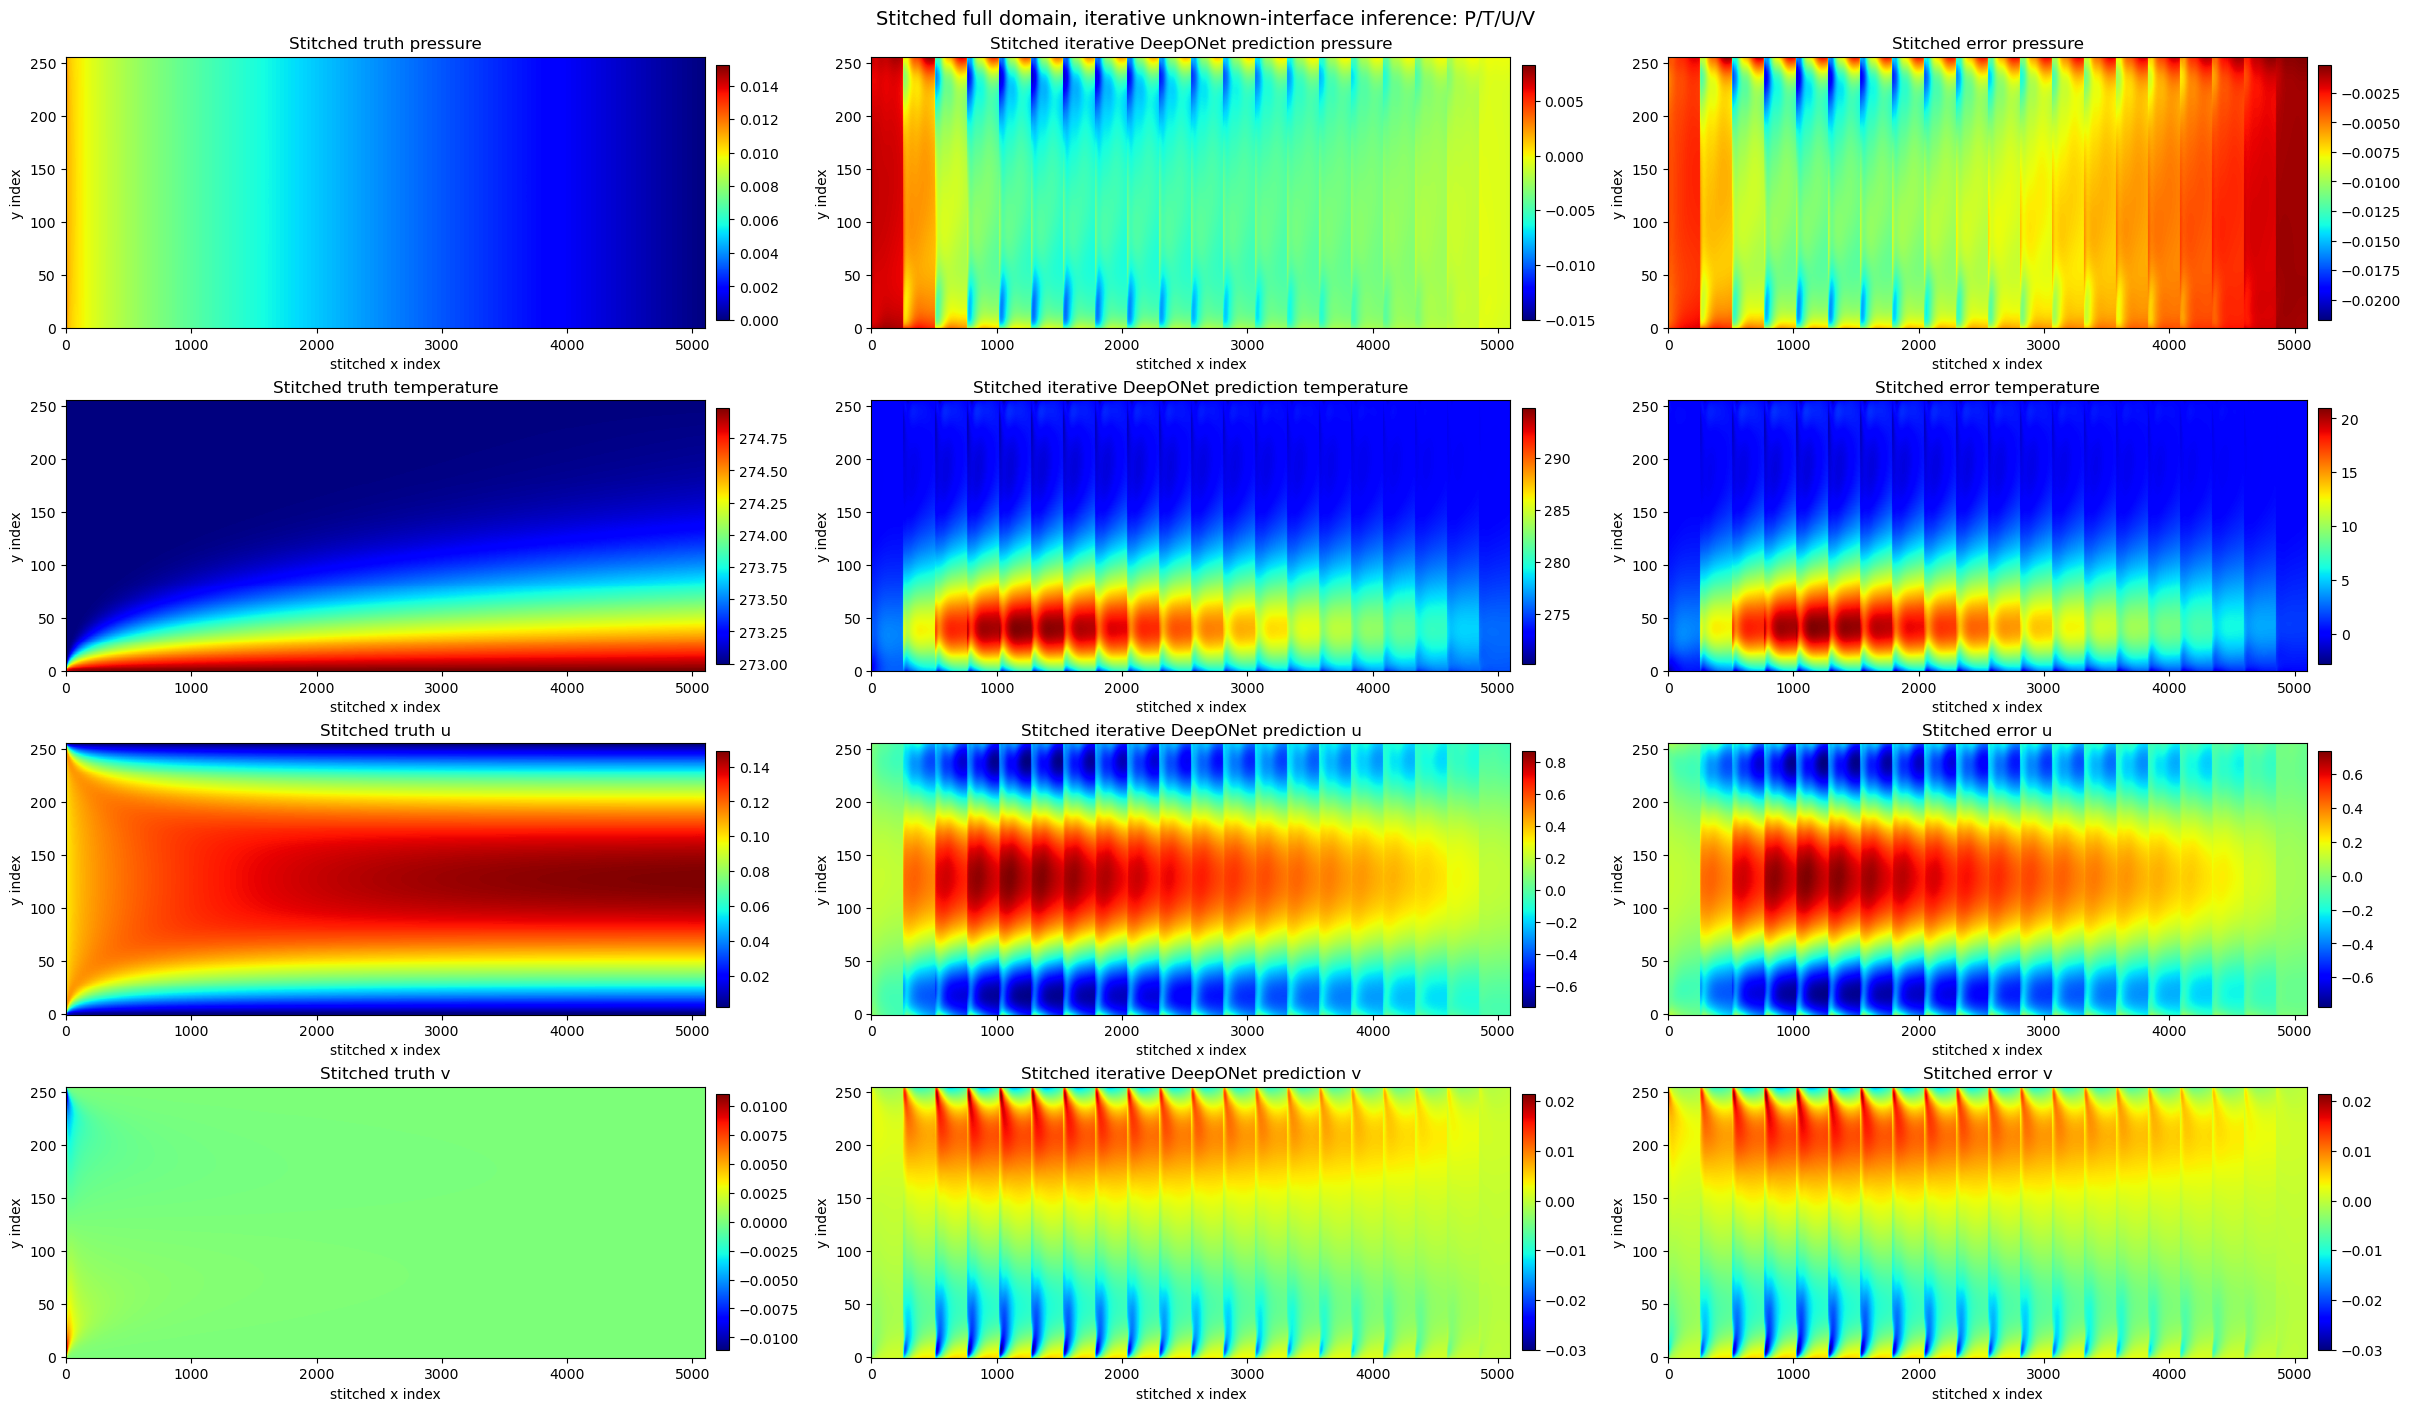

In [ ]:
err_stitched = pred_stitched - truth_stitched

fig, axes = plt.subplots(
    len(output_channel_names),
    3,
    figsize=(24, 14),
    constrained_layout=True,
)

for fi, fname in enumerate(output_channel_names):
    truth_f = truth_stitched[:, :, fi]
    pred_f = pred_stitched[:, :, fi]
    err_f = err_stitched[:, :, fi]

    im0 = axes[fi, 0].imshow(truth_f.T, origin="lower", aspect="auto", cmap="jet")
    axes[fi, 0].set_title(f"Stitched truth {fname}")
    axes[fi, 0].set_xlabel("stitched x index")
    axes[fi, 0].set_ylabel("y index")
    plt.colorbar(im0, ax=axes[fi, 0], fraction=0.02, pad=0.01)

    im1 = axes[fi, 1].imshow(pred_f.T, origin="lower", aspect="auto", cmap="jet")
    axes[fi, 1].set_title(f"Stitched iterative DeepONet prediction {fname}")
    axes[fi, 1].set_xlabel("stitched x index")
    axes[fi, 1].set_ylabel("y index")
    plt.colorbar(im1, ax=axes[fi, 1], fraction=0.02, pad=0.01)

    im2 = axes[fi, 2].imshow(err_f.T, origin="lower", aspect="auto", cmap="jet")
    axes[fi, 2].set_title(f"Stitched error {fname}")
    axes[fi, 2].set_xlabel("stitched x index")
    axes[fi, 2].set_ylabel("y index")
    plt.colorbar(im2, ax=axes[fi, 2], fraction=0.02, pad=0.01)

fig.suptitle(
    "Stitched full domain, iterative unknown-interface inference: P/T/U/V",
    fontsize=14,
)
plt.show()